# Descarga de información

Jonathan Ivan Salmoran Acuña

### Librería

In [70]:
from os.path import normcase
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
import seaborn as sns
from scipy import stats
from ydata_profiling import ProfileReport
from scipy.stats import norm
from plotly.subplots import make_subplots
import plotly.express as px

#Escondemos los warnings
import warnings
warnings.filterwarnings('ignore')

In [71]:

# Codigo yfinance

# descarrgamos los precios históricos de las acciones utilizando yfinance

# nombre acciones 
# OMAB.MX, COST.MX, JNJ.MX, NFLX.MX, LIVERPOLC-1.MX, BABAN.MX, MEGACPO.MX, KOFUBL.MX, KIMBERA.MX, BIDUN.MX
nombre_acciones = ["GFNORTEO.MX", "WALMEX.MX", "GMEXICOB.MX", "CEMEXCPO.MX", "MSFT.MX", "AAPL.MX", "AMZN.MX", "GENTERA.MX", "GOOGL.MX", "NVDA.MX"]
#nombre_acciones = ["AAPL","MSFT","GOOGL","TSLA","AMZN"]
 
#Creamos una "cajita" para almacenar los datos
recolector = []
for nemo in nombre_acciones:
    #Obtenemos el ticker utilizando yfinance
    ticker = yf.Ticker(nemo)
    
    #Obtenemos los datos/precio de cierre a 2 años (fijamos la fecha de 07/05/2026)
    px = ticker.history(start = "2024-05-07", end="2026-05-07")["Close"]
    px.name = nemo
    #Agregamos a la "lista"
    recolector.append(px)

precios = pd.concat(recolector, axis=1)
precios

,GFNORTEO.MX,WALMEX.MX,GMEXICOB.MX,CEMEXCPO.MX,MSFT.MX,AAPL.MX,AMZN.MX,GENTERA.MX,GOOGL.MX,NVDA.MX
Date,,,,,,,,,,
2024-05-07 00:00:00-06:00,142.999725,61.224812,96.243080,13.048884,6923.490234,3079.548828,3181.989990,23.843126,2885.024414,1528.497803
2024-05-08 00:00:00-06:00,144.173416,62.131359,93.700668,12.920666,6909.434082,3088.074219,3174.370117,23.384775,2853.078125,1529.360718
2024-05-09 00:00:00-06:00,145.231400,64.037910,95.846970,13.029159,6919.494141,3101.737061,3181.500000,23.663380,2845.941162,1489.068115
2024-05-10 00:00:00-06:00,145.156998,64.551933,95.616692,13.137652,6953.462402,3069.921875,3149.610107,24.704277,2824.850342,1506.100464
2024-05-13 00:00:00-06:00,146.826599,63.916420,94.244156,13.167243,6939.205078,3140.559570,3130.100098,24.760767,2830.177979,1518.572021
...,...,...,...,...,...,...,...,...,...,...
2026-04-29 00:00:00-06:00,189.250000,55.400002,190.139999,21.360001,7435.910645,4734.847168,4598.870117,45.980000,6148.890137,3661.639893
2026-04-30 00:00:00-06:00,190.369995,55.230000,191.500000,21.459999,7144.997559,4762.485352,4637.700195,45.650002,6705.770020,3498.679932
2026-05-04 00:00:00-06:00,189.020004,53.990002,189.080002,20.799999,7231.046875,4855.660156,4755.540039,45.060001,6706.540039,3481.000000


In [72]:
precios = precios.ffill()
precios

,GFNORTEO.MX,WALMEX.MX,GMEXICOB.MX,CEMEXCPO.MX,MSFT.MX,AAPL.MX,AMZN.MX,GENTERA.MX,GOOGL.MX,NVDA.MX
Date,,,,,,,,,,
2024-05-07 00:00:00-06:00,142.999725,61.224812,96.243080,13.048884,6923.490234,3079.548828,3181.989990,23.843126,2885.024414,1528.497803
2024-05-08 00:00:00-06:00,144.173416,62.131359,93.700668,12.920666,6909.434082,3088.074219,3174.370117,23.384775,2853.078125,1529.360718
2024-05-09 00:00:00-06:00,145.231400,64.037910,95.846970,13.029159,6919.494141,3101.737061,3181.500000,23.663380,2845.941162,1489.068115
2024-05-10 00:00:00-06:00,145.156998,64.551933,95.616692,13.137652,6953.462402,3069.921875,3149.610107,24.704277,2824.850342,1506.100464
2024-05-13 00:00:00-06:00,146.826599,63.916420,94.244156,13.167243,6939.205078,3140.559570,3130.100098,24.760767,2830.177979,1518.572021
...,...,...,...,...,...,...,...,...,...,...
2026-04-29 00:00:00-06:00,189.250000,55.400002,190.139999,21.360001,7435.910645,4734.847168,4598.870117,45.980000,6148.890137,3661.639893
2026-04-30 00:00:00-06:00,190.369995,55.230000,191.500000,21.459999,7144.997559,4762.485352,4637.700195,45.650002,6705.770020,3498.679932
2026-05-04 00:00:00-06:00,189.020004,53.990002,189.080002,20.799999,7231.046875,4855.660156,4755.540039,45.060001,6706.540039,3481.000000


### Descarga de informacion

In [73]:
print(recolector)

[Date
2024-05-07 00:00:00-06:00    142.999725
2024-05-08 00:00:00-06:00    144.173416
2024-05-09 00:00:00-06:00    145.231400
2024-05-10 00:00:00-06:00    145.156998
2024-05-13 00:00:00-06:00    146.826599
                                ...    
2026-04-29 00:00:00-06:00    189.250000
2026-04-30 00:00:00-06:00    190.369995
2026-05-04 00:00:00-06:00    189.020004
2026-05-05 00:00:00-06:00    188.960007
2026-05-06 00:00:00-06:00    192.630005
Name: GFNORTEO.MX, Length: 500, dtype: float64, Date
2024-05-07 00:00:00-06:00    61.224812
2024-05-08 00:00:00-06:00    62.131359
2024-05-09 00:00:00-06:00    64.037910
2024-05-10 00:00:00-06:00    64.551933
2024-05-13 00:00:00-06:00    63.916420
                               ...    
2026-04-29 00:00:00-06:00    55.400002
2026-04-30 00:00:00-06:00    55.230000
2026-05-04 00:00:00-06:00    53.990002
2026-05-05 00:00:00-06:00    55.500000
2026-05-06 00:00:00-06:00    55.820000
Name: WALMEX.MX, Length: 500, dtype: float64, Date
2024-05-07 00:00:00-0

In [74]:
precios

,GFNORTEO.MX,WALMEX.MX,GMEXICOB.MX,CEMEXCPO.MX,MSFT.MX,AAPL.MX,AMZN.MX,GENTERA.MX,GOOGL.MX,NVDA.MX
Date,,,,,,,,,,
2024-05-07 00:00:00-06:00,142.999725,61.224812,96.243080,13.048884,6923.490234,3079.548828,3181.989990,23.843126,2885.024414,1528.497803
2024-05-08 00:00:00-06:00,144.173416,62.131359,93.700668,12.920666,6909.434082,3088.074219,3174.370117,23.384775,2853.078125,1529.360718
2024-05-09 00:00:00-06:00,145.231400,64.037910,95.846970,13.029159,6919.494141,3101.737061,3181.500000,23.663380,2845.941162,1489.068115
2024-05-10 00:00:00-06:00,145.156998,64.551933,95.616692,13.137652,6953.462402,3069.921875,3149.610107,24.704277,2824.850342,1506.100464
2024-05-13 00:00:00-06:00,146.826599,63.916420,94.244156,13.167243,6939.205078,3140.559570,3130.100098,24.760767,2830.177979,1518.572021
...,...,...,...,...,...,...,...,...,...,...
2026-04-29 00:00:00-06:00,189.250000,55.400002,190.139999,21.360001,7435.910645,4734.847168,4598.870117,45.980000,6148.890137,3661.639893
2026-04-30 00:00:00-06:00,190.369995,55.230000,191.500000,21.459999,7144.997559,4762.485352,4637.700195,45.650002,6705.770020,3498.679932
2026-05-04 00:00:00-06:00,189.020004,53.990002,189.080002,20.799999,7231.046875,4855.660156,4755.540039,45.060001,6706.540039,3481.000000


### Informacion inicial del portafolio

In [75]:
# Cuanto vamos a invertir
monto_inversion = 1_000_000
# Cambiamos formato
monto_inversion2= "${:,.2f}".format(monto_inversion)

# "${:,.2f}" --> Define como vamos a "presentar" nuestro numero
# --> $/% simbolo (fuera de las llaves)
#{:} --> introduce/inicia el formato
# , --> separar por miles
# .2f --> 2f, 3f ...num de decimales que quiero mostrar


#precio actual
#regresa el ultimo valor de nuestro DataFrame
precio_activos = precios.iloc[-1]

#.iloc --> selecciona filas y columnas (empezamos desde cero)

# si "K" es un num de fila y "r" es el num de la columna r
# .iloc[k,r] --> valor fila k y columna r
# .iloc[:,r] --> columna r
# .iloc[k , :] --> fila k

# .loc[:15, :3] --> las primeras 15 filas y las primeras 3 columnas
# .iloc[17:n , :3] --> todas las filas desde la poss 17 hasta el final de las 3 primeras columnas
precio_activos

#Cambiemos el formato
precio_activos_dinero = precio_activos.apply("${:,.2f}".format)
precio_activos_dinero


GFNORTEO.MX      $192.63
WALMEX.MX         $55.82
GMEXICOB.MX      $202.22
CEMEXCPO.MX       $23.40
MSFT.MX        $7,135.84
AAPL.MX        $4,952.69
AMZN.MX        $4,763.63
GENTERA.MX        $47.06
GOOGL.MX       $6,850.54
NVDA.MX        $3,580.14
Name: 2026-05-06 00:00:00-06:00, dtype: object

In [76]:
monto_inversion2

'$1,000,000.00'

### Rendimientos Ln()

In [77]:
#rendimientos --> ln(i/i-1)

#shift(1) --> desplaza una fila abajo
rendimientos = np.log(precios / precios.shift(1))

# Ln (A/B) = {In(A) - In(B)}

# Quitamos el NaN utilizando el .droppna
rendimientos.dropna(inplace=True)

#inplace = True --> Los cambios se aplican directamente al DataFrame original
# False --> (Valor por defecto) devuelve un nuevo DataFrame dejando el original sin modificar



# numero de dias cotizados y num de activos
num_filas = len(rendimientos.axes[0]) # --> Num de dias cotizados
num_columnas = len(rendimientos.axes[1]) # --> Num de activos

# len --> mide una longitud/ contar
# axes --> devuelve una lista de los "ejes"/dimensiones
# axes[0] --> es el primer eje y corresponde al índice de las filas del DataFrame
# axes[1] --> es el primer eje y corresponde al índice de las columnas del DataFrame


num_filas

500

In [78]:
precios.shift(1)

,GFNORTEO.MX,WALMEX.MX,GMEXICOB.MX,CEMEXCPO.MX,MSFT.MX,AAPL.MX,AMZN.MX,GENTERA.MX,GOOGL.MX,NVDA.MX
Date,,,,,,,,,,
2024-05-07 00:00:00-06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-08 00:00:00-06:00,142.999725,61.224812,96.243080,13.048884,6923.490234,3079.548828,3181.989990,23.843126,2885.024414,1528.497803
2024-05-09 00:00:00-06:00,144.173416,62.131359,93.700668,12.920666,6909.434082,3088.074219,3174.370117,23.384775,2853.078125,1529.360718
2024-05-10 00:00:00-06:00,145.231400,64.037910,95.846970,13.029159,6919.494141,3101.737061,3181.500000,23.663380,2845.941162,1489.068115
2024-05-13 00:00:00-06:00,145.156998,64.551933,95.616692,13.137652,6953.462402,3069.921875,3149.610107,24.704277,2824.850342,1506.100464
...,...,...,...,...,...,...,...,...,...,...
2026-04-29 00:00:00-06:00,192.500000,53.279999,188.619995,21.059999,7465.457520,4703.748535,4508.569824,46.959999,6085.000000,3710.560059
2026-04-30 00:00:00-06:00,189.250000,55.400002,190.139999,21.360001,7435.910645,4734.847168,4598.870117,45.980000,6148.890137,3661.639893
2026-05-04 00:00:00-06:00,190.369995,55.230000,191.500000,21.459999,7144.997559,4762.485352,4637.700195,45.650002,6705.770020,3498.679932


# Esperanza activos

In [79]:
# Esperanza --> media aritmética


# Obtenemos el promedio
esperanza_activos = rendimientos.mean()

#lo convertimos a porcentaje

esperanza_activos_porcentaje = esperanza_activos * 100

#cambiamos el formato
esperanza_activos_porcentaje = esperanza_activos_porcentaje.apply("{:.5f}%".format)

esperanza_activos_porcentaje

GFNORTEO.MX     0.05959%
WALMEX.MX      -0.01848%
GMEXICOB.MX     0.14850%
CEMEXCPO.MX     0.11681%
MSFT.MX         0.00604%
AAPL.MX         0.09503%
AMZN.MX         0.08070%
GENTERA.MX      0.13599%
GOOGL.MX        0.17296%
NVDA.MX         0.17022%
dtype: object

# Riesgo activos

In [80]:
# muestral / poblacional

# obtenemos la desv. estandar de los activos
riesgo_activos = rendimientos.std(ddof = 0)

# ddof = 0 --> dev. estandar muestral
# ddof = 1 --> dev. estandar poblacional

#lo convertimos a porcentaje

riesgo_activos_porcentaje = riesgo_activos * 100

#cambiamos el formato
riesgo_activos_porcentaje = riesgo_activos_porcentaje.apply("{:.5f}%".format)

riesgo_activos_porcentaje


GFNORTEO.MX    1.93482%
WALMEX.MX      1.68929%
GMEXICOB.MX    2.25048%
CEMEXCPO.MX    2.14943%
MSFT.MX        1.65333%
AAPL.MX        1.82346%
AMZN.MX        2.00397%
GENTERA.MX     2.36809%
GOOGL.MX       1.86887%
NVDA.MX        2.95316%
dtype: object

# Información inicial de los activos

In [81]:
# hacemos una tabla con la información obtenida anteriormente

# creamos un  DataFrame

# columnas --> Nombre de los activos
# filas -- info

df_activos_inf = pd.DataFrame(columns = nombre_acciones, index = ["Precio actual", "Esperanza activo", "Riesgo activo"])

# agreguemos la informacion
df_activos_inf.loc["Precio actual"] = precio_activos_dinero
df_activos_inf.loc["Esperanza activo"] = esperanza_activos_porcentaje
df_activos_inf.loc["Riesgo activo"] = riesgo_activos_porcentaje


df_activos_inf.T

# .T --> Sirve para transponer

,Precio actual,Esperanza activo,Riesgo activo
GFNORTEO.MX,$192.63,0.05959%,1.93482%
WALMEX.MX,$55.82,-0.01848%,1.68929%
GMEXICOB.MX,$202.22,0.14850%,2.25048%
CEMEXCPO.MX,$23.40,0.11681%,2.14943%
MSFT.MX,"$7,135.84",0.00604%,1.65333%
AAPL.MX,"$4,952.69",0.09503%,1.82346%
AMZN.MX,"$4,763.63",0.08070%,2.00397%
GENTERA.MX,$47.06,0.13599%,2.36809%
GOOGL.MX,"$6,850.54",0.17296%,1.86887%
NVDA.MX,"$3,580.14",0.17022%,2.95316%


In [82]:
df_activos_inf

,GFNORTEO.MX,WALMEX.MX,GMEXICOB.MX,CEMEXCPO.MX,MSFT.MX,AAPL.MX,AMZN.MX,GENTERA.MX,GOOGL.MX,NVDA.MX
Precio actual,$192.63,$55.82,$202.22,$23.40,"$7,135.84","$4,952.69","$4,763.63",$47.06,"$6,850.54","$3,580.14"
Esperanza activo,0.05959%,-0.01848%,0.14850%,0.11681%,0.00604%,0.09503%,0.08070%,0.13599%,0.17296%,0.17022%
Riesgo activo,1.93482%,1.68929%,2.25048%,2.14943%,1.65333%,1.82346%,2.00397%,2.36809%,1.86887%,2.95316%


# Tasa libre de riesgo

In [83]:
# definimos nuestra tasa libre de riesgo

#tas cetes
tasa_cetes = 0.065/252 #convertimos la tasa anual a diaria dividiendo entre 252 (num de dias cotizados en un año)

#excedentes_rendimiento
excedentes_rend = esperanza_activos - tasa_cetes





# Portafolios Optimos

## Matrices

In [84]:
# matriz de varianza cov

# matriz principal
matriz_var_principal = np.cov(rendimientos, y = None, rowvar = 0, bias = False)

 # y = None --> Indicamosla covarianza entre todas las columnas
# rowvar = False /0 --> Cada col es una variable y cada fila una observacion
# bias = True --> Indica poblacional // bias = False --> Indica muestral
        # ddof = None --> grados libertad --> (n-1)

# matriz inv principal
matriz_inv_principal = np.linalg.inv(matriz_var_principal)

In [85]:
# matriz con 1/0

# matriz con uno´s a la matriz principal /// columnas
matriz_var1 = np.insert(matriz_var_principal, num_columnas, [1], axis = 1)

# matriz con uno´s a la matriz principal (completa) /// columnas
matriz_var1 = np.insert(matriz_var1, num_columnas, [1], axis = 0)

# .insert(a quien?. donde?, que?, como? cuando?)

# num_columnas --> si nuestra matriz tiene N columnas (0 a n-1)
#inserta en la poss N -- añade una nueva columna al final de la matriz

# [1] -- inserta los valores (a repetir), añade tantos 1´s como sean necesarios para llenar la columna
# axis -- eje en el cual vamos a añadir
# axis = 1 -- filas
# axis = 0 -- columnas



# modificamos el valor (ultima fila, ultima columna) a 0
#(fila,columna)

matriz_var1[num_columnas, num_columnas] = 0


# matriz inversa de uno´s y cero
matriz_inv_unos = np.linalg.inv(matriz_var1)

In [86]:
# matriz con esperanzas

# añadimos un cero a las esperanzas
esperanza_con_cero = np.insert(esperanza_activos, num_columnas, [0], axis = 0)

#agregamos el segundo cero a la esperanza
esperanza_con_2ceros = np.insert(esperanza_con_cero, num_columnas, [0], axis = 0)

matriz_rend = np.insert(matriz_var1, num_columnas + 1 , esperanza_con_cero, axis = 1)
matriz_rend = np.insert(matriz_rend, num_columnas + 1 , esperanza_con_2ceros, axis = 0)

# inversa de la matriz con esp
matriz_inv_rend = np.linalg.inv(matriz_rend)



In [87]:
matriz_rend

array([[ 3.75102715e-04,  1.17978783e-04,  1.67704541e-04,
         1.06594064e-04, -2.37290023e-05, -1.39436017e-05,
        -4.48939180e-06,  1.88174812e-04, -1.11300535e-06,
         3.93265070e-05,  1.00000000e+00,  5.95857133e-04],
       [ 1.17978783e-04,  2.85942016e-04,  1.01126654e-04,
         7.95322345e-05, -2.07299493e-05, -7.94986174e-06,
        -5.83272764e-06,  8.69657477e-05, -1.96917918e-05,
         4.06712097e-06,  1.00000000e+00, -1.84840605e-04],
       [ 1.67704541e-04,  1.01126654e-04,  5.07481761e-04,
         1.53558554e-04, -2.54058193e-05,  3.14164803e-05,
         3.90441319e-05,  1.12983061e-04,  5.25488586e-05,
         7.86766724e-05,  1.00000000e+00,  1.48495829e-03],
       [ 1.06594064e-04,  7.95322345e-05,  1.53558554e-04,
         4.62929640e-04,  2.71305944e-05,  5.07639366e-05,
         9.05052913e-05,  1.28424342e-04,  4.20041817e-05,
         1.16743160e-04,  1.00000000e+00,  1.16806673e-03],
       [-2.37290023e-05, -2.07299493e-05, -2.5405819

## Portafolio de mínimo riesgo (MR)

In [88]:
# Portafolio MR _____________________________
# Obtención de pesos

# Extraemos los pesos del portafolio de mínimo riesgo de la matriz inversa
# La última columna de matriz_inv_unos contiene los pesos del MVP
wi_MR = matriz_inv_unos[:-1, -1]

# Normalizamos los pesos para que sumen a 1
suma_wi_MR = np.sum(wi_MR)
wi_MR = wi_MR / suma_wi_MR

# Calculamos la esperanza del portafolio MVP
esp_port_MR = wi_MR @ esperanza_activos
esp_port_porcentaje_MR = esp_port_MR * 100
esp_port_porcentaje_MR = "{:.5f}%".format(esp_port_porcentaje_MR)


In [140]:
# Posición, valuación
# Calculamos el riesgo del portafolio MVP
riesgo_port_MR = np.sqrt(wi_MR @ matriz_var_principal @ wi_MR)
riesgo_port_porcentaje_MR = riesgo_port_MR * 100
riesgo_port_porcentaje_MR = "{:.5f}%".format(riesgo_port_porcentaje_MR)

# Monto asignado a cada activo
asignacion_activos_MR = abs(wi_MR*monto_inversion)
asignacion_activos_dinero_MR = ["${:2f}".format(i) for i in asignacion_activos_MR]

# Posición de activos
posicion_activos_MR = np.floor(asignacion_activos_MR / precio_activos)
posicion_port_MR = posicion_activos_MR.sum()
posicion_activos_dinero_MR = ["{:,.2f}".format(i) for i in posicion_activos_MR]

# Valuación del portafolio
val_activos_MR = posicion_activos_MR * precio_activos
val_activos_dinero_MR = ["${:,.5f}".format(i) for i in val_activos_MR]
val_port_MR = val_activos_MR.sum()
val_port_dinero_MR = "${:,.5f}".format(val_port_MR)

In [141]:
# Tabla del portafolio de mínimo riesgo
df_port_MR = pd.DataFrame(columns=["Portafolio eficiente MR"],index = ["Posición del portafolio","Valuación del portafolio", "Esperanza del portafolio", "Riesgo del portafolio"])

df_port_MR.loc["Posición del portafolio"] = posicion_port_MR
df_port_MR.loc["Valuación del portafolio"] = val_port_dinero_MR
df_port_MR.loc["Esperanza del portafolio"] = esp_port_porcentaje_MR
df_port_MR.loc["Riesgo del portafolio"] = riesgo_port_porcentaje_MR

# Información de los activos
df_wi_MR = pd.DataFrame(columns= nombre_acciones, index=["Peso de los activos"])
df_wi_MR[nombre_acciones] = wi_MR
df_wi_MR.loc["Asignacion de los activos"] = asignacion_activos_dinero_MR
df_wi_MR.loc["Posicion de los activos"] = posicion_activos_dinero_MR
df_wi_MR.loc["Valuacion de los activos"] = val_activos_dinero_MR

print(df_port_MR)
print(df_wi_MR)

                         Portafolio eficiente MR
Posición del portafolio                   8850.0
Valuación del portafolio        $1,099,460.04328
Esperanza del portafolio                0.05413%
Riesgo del portafolio                   0.92120%
                              GFNORTEO.MX       WALMEX.MX    GMEXICOB.MX  \
Peso de los activos              0.103813        0.229993       0.055015   
Asignacion de los activos  $103812.776621  $229992.959029  $55014.605144   
Posicion de los activos            538.00        4,120.00         272.00   
Valuacion de los activos   $103,634.94263  $229,978.39874  $55,003.84033   

                             CEMEXCPO.MX         MSFT.MX         AAPL.MX  \
Peso de los activos             0.051373        0.280368         0.13171   
Asignacion de los activos  $51373.283812  $280368.239338  $131709.514708   
Posicion de los activos         2,195.00           39.00           26.00   
Valuacion de los activos   $51,362.99916  $278,297.69678  $128,769.824

In [91]:
# hacemos vector al wi_M y lo acostamos
wi_MR_vector = wi_MR.reshape(-1,1).T
wi_MR_vector.tolist()

[[0.10381277662092314,
  0.2299929590285487,
  0.05501460514445187,
  0.051373283811701365,
  0.2803682393379216,
  0.1317095147076035,
  -0.010536292009690838,
  0.07664732595369572,
  0.12626429183165178,
  -0.044646704426806946]]

## Portafolio de Mercado (M)

In [92]:
# Portafolio M _________________________________________________

#Multiplicamos la matriz inversa con los exc de rend    
matriz_mult = matriz_inv_principal @ excedentes_rend

#Hacemos la suma correspondiente de la mult de las anterioes matrices 

suma_matriz = sum(matriz_mult)

# Dividimos la multiplicacón con la suma de las matrices anteriores 
div_matriz_M = matriz_mult / suma_matriz

#transponemos y obtenemos los pesos del portafolio M
wi_M = np.transpose(div_matriz_M)

#Esperanza y riesgo del portafolio________________________________

#Obtenemos la esperanza del portafolio
esp_port_M = wi_M @ esperanza_activos
#Lo convertimos a porcentaje
esp_port_porcentaje_M = esp_port_M * 100
esp_port_porcentaje_M = "{:.5f}%".format(esp_port_porcentaje_M)



#Obtenemos el riesgo del portafolio

riesgo_port_M = np.sqrt(wi_M @ matriz_var_principal @ wi_M)

#Lo convertimos a porcentaje
riesgo_port_porcentaje_M = riesgo_port_M * 100
riesgo_port_porcentaje_M = "{:.5f}%".format(riesgo_port_porcentaje_M)

riesgo_port_porcentaje_M, esp_port_porcentaje_M

('3.63103%', '0.46598%')

In [ ]:
# Monto asignado a cada activo 
asignacion_activos_M = abs(wi_M*monto_inversion)
asignacion_activos_dinero_M = ["${:2f}".format(i) for i in asignacion_activos_M]

# posicion --- num de activos actuales
posicion_activos_M = np.floor(asignacion_activos_M/precio_activos)
posicion_activos_dinero_M = ["{:2f}".format(i) for i in posicion_activos_M]
posicion_port_M = posicion_activos_M.sum()

# valuación ---> Cuánto vale mi portafolio /// cuanto dinero tengo invertido
# por activo ---> portafolio

val_activos_M = posicion_activos_M * precio_activos
val_activos_dinero_M = ["${:2f}".format(i) for i in val_activos_M]

# val del port

val_port_M =  val_activos_M.sum()
val_port_dinero_M = "${:,.5f}".format(val_port_M)
val_port_dinero_M

'$5,300,521.07740'

In [94]:
#tabla del portafolio de Mercado

# agregamos la inf a la tabla

df_port_M = pd.DataFrame(columns=["Portafolio eficiente M."], index= ["Posición del portafolio", "Valuación del portafolio", "Esperanza del portafolio", "Riesgo del portafolio"])

df_port_M.loc["Posición del portafolio"] = posicion_port_M
df_port_M.loc["Valuación del portafolio"] = val_port_dinero_M
df_port_M.loc["Esperanza del portafolio"] = esp_port_porcentaje_M
df_port_M.loc["Riesgo del portafolio"] = riesgo_port_porcentaje_M

# Inf de los activos

df_wi_M = pd.DataFrame(columns = nombre_acciones, index=["Peso de los activos"])

df_wi_M[nombre_acciones] = wi_M
df_wi_M.loc["Asignacion de los activos"] = asignacion_activos_dinero_M
df_wi_M.loc["Posicion de los activos"] = posicion_activos_dinero_M
df_wi_M.loc["Valuacion de los activos"] = val_activos_dinero_M


print(df_port_M)
print(df_wi_M)

                         Portafolio eficiente M.
Posición del portafolio                  42633.0
Valuación del portafolio        $5,300,521.07740
Esperanza del portafolio                0.46598%
Riesgo del portafolio                   3.63103%
                              GFNORTEO.MX       WALMEX.MX     GMEXICOB.MX  \
Peso de los activos             -0.130059       -0.815246        0.479862   
Asignacion de los activos  $130059.063018  $815246.024818  $479861.530881   
Posicion de los activos       $675.000000   $14604.000000    $2372.000000   
Valuacion de los activos   $130025.253296  $815195.275543  $479665.842896   

                              CEMEXCPO.MX          MSFT.MX         AAPL.MX  \
Peso de los activos              0.320429        -1.027931        0.214305   
Asignacion de los activos  $320428.967894  $1027930.891747  $214305.319482   
Posicion de los activos     $13693.000000      $144.000000      $43.000000   
Valuacion de los activos   $320416.194777  $1027560.72656

## Portafolio de Rendimiento Deseado (RD)

In [95]:
# Portafolio de Rendimiento deseado

# ponemos el rendimiento que queremos obtener (En decimal)
rend_deseado = 0.0008

# A --- Penultima columna 
# B ---- Ultima columna

# A + B * rend

#tomamos la última columna/fila de la matriz con rendimientos

submatrizA = matriz_inv_rend[-1]

# multiplicamos esa columna con el rendimiento dado

mult_submatriz = submatrizA * rend_deseado

# sumamos la penultima columna/fila 
submatrizB = matriz_inv_rend[-2]

#sumamos (B + A * rend)

suma_columnasAB = submatrizB + mult_submatriz

#Obtenemos n entradas del vector con n num de activos 
wi_RD = suma_columnasAB[:num_columnas]

#Esperanza y riesgo del portafolio________________________________

#Obtenemos el rend del portafolio
esp_port_RD = wi_RD @ esperanza_activos
#Lo convertimos a porcentaje
esp_port_porcentaje_RD = esp_port_RD * 100
esp_port_porcentaje_RD = "{:.5f}%".format(esp_port_porcentaje_RD)



#Obtenemos el riesgo del portafolio

riesgo_port_RD = np.sqrt(wi_RD @ matriz_var_principal @ wi_RD)

#Lo convertimos a porcentaje
riesgo_port_porcentaje_RD = riesgo_port_RD * 100
riesgo_port_porcentaje_RD = "{:.5f}%".format(riesgo_port_porcentaje_RD)




In [96]:
# Monto asignado a cada activo 
asignacion_activos_RD = abs(wi_RD*monto_inversion)
asignacion_activos_dinero_RD = ["${:2f}".format(i) for i in asignacion_activos_RD]

# posicion --- num de activos actuales
posicion_activos_RD = np.floor(asignacion_activos_RD/precio_activos)
posicion_activos_dinero_RD = ["${:2f}".format(i) for i in posicion_activos_RD]
posicion_port_RD = posicion_activos_RD.sum()

# valuación ---> Cuánto vale mi portafolio /// cuanto dinero tengo invertido
# por activo ---> portafolio

val_activos_RD = posicion_activos_RD * precio_activos
val_activos_dinero_RD = ["${:2f}".format(i) for i in val_activos_RD]

# val del port

val_port_RD =  val_activos_RD.sum()
val_port_dinero_RD = "${:,.5f}".format(val_port_RD)

In [97]:
#tabla del portafolio de Rendimiento deseado

# agregamos la inf a la tabla

df_port_RD = pd.DataFrame(columns=["Portafolio eficiente RD."], index= ["Posición del portafolio", "Valuación del portafolio", "Esperanza del portafolio", "Riesgo del portafolio"])

df_port_RD.loc["Posición del portafolio"] = posicion_port_RD
df_port_RD.loc["Valuación del portafolio"] = val_port_dinero_RD
df_port_RD.loc["Esperanza del portafolio"] = esp_port_porcentaje_RD
df_port_RD.loc["Riesgo del portafolio"] = riesgo_port_porcentaje_RD

# Inf de los activos

df_wi_RD = pd.DataFrame(columns = nombre_acciones, index=["Peso de los activos"])

df_wi_RD[nombre_acciones] = wi_RD
df_wi_RD.loc["Asignacion de los activos"] = asignacion_activos_dinero_RD
df_wi_RD.loc["Posicion de los activos"] = posicion_activos_dinero_RD
df_wi_RD.loc["Valuacion de los activos"] = val_activos_dinero_RD


print(df_port_RD)
print(df_wi_RD)

                         Portafolio eficiente RD.
Posición del portafolio                    9019.0
Valuación del portafolio         $1,058,481.52995
Esperanza del portafolio                 0.08000%
Riesgo del portafolio                    0.94726%
                             GFNORTEO.MX       WALMEX.MX    GMEXICOB.MX  \
Peso de los activos              0.08912        0.164328       0.081705   
Asignacion de los activos  $89120.213684  $164327.765740  $81704.822336   
Posicion de los activos      $462.000000    $2943.000000    $404.000000   
Valuacion de los activos   $88995.062256  $164278.259102  $81696.880493   

                             CEMEXCPO.MX         MSFT.MX         AAPL.MX  \
Peso de los activos             0.068276        0.198177        0.136898   
Asignacion de los activos  $68276.206276  $198176.782026  $136898.442378   
Posicion de los activos     $2917.000000      $27.000000      $27.000000   
Valuacion de los activos   $68257.798887  $192667.636230  $133722.5097

## Portafolio ajustado (A)

In [98]:
#Creamos el portafolio Ajustado (A), con base al port de ren deseado

wi_A = np.where(wi_RD > 0, wi_RD, 0)

#np.where ----> similar a if/else
# np.where(Condicion, SI PASA ENTONCES..., SI NO PASA ... ESTO)

#Obtenemos el rend del portafolio
esp_port_A = wi_A @ esperanza_activos
#Lo convertimos a porcentaje
esp_port_porcentaje_A = esp_port_A * 100
esp_port_porcentaje_A = "{:.5f}%".format(esp_port_porcentaje_A)



#Obtenemos el riesgo del portafolio

riesgo_port_A = np.sqrt(wi_A @ matriz_var_principal @ wi_A)

#Lo convertimos a porcentaje
riesgo_port_porcentaje_A = riesgo_port_A * 100
riesgo_port_porcentaje_A = "{:.5f}%".format(riesgo_port_porcentaje_A)



In [99]:
# Monto asignado a cada activo
asignacion_activos_A = abs(wi_A*monto_inversion)
asignacion_activos_dinero_A = ["${:2f}".format(i) for i in asignacion_activos_A]

# posicion --- num de activos actuales
posicion_activos_A = np.floor(asignacion_activos_A/precio_activos)
posicion_activos_dinero_A = ["${:2f}".format(i) for i in posicion_activos_A]
posicion_port_A = posicion_activos_A.sum()

# valuación ---> Cuánto vale mi portafolio /// cuanto dinero tengo invertido
# por activo ---> portafolio

val_activos_A = posicion_activos_A * precio_activos
val_activos_dinero_A = ["${:2f}".format(i) for i in val_activos_A]

# val del port

val_port_A =  val_activos_A.sum()
val_port_dinero_A = "${:,.5f}".format(val_port_A)

In [100]:
#tabla del portafolio de Rendimiento deseado

# agregamos la inf a la tabla

df_port_A = pd.DataFrame(columns=["Portafolio eficiente A."], index= ["Posición del portafolio", "Valuación del portafolio", "Esperanza del portafolio", "Riesgo del portafolio"])

df_port_A.loc["Posición del portafolio"] = posicion_port_A
df_port_A.loc["Valuación del portafolio"] = val_port_dinero_A
df_port_A.loc["Esperanza del portafolio"] = esp_port_porcentaje_A
df_port_A.loc["Riesgo del portafolio"] = riesgo_port_porcentaje_A

# Inf de los activos

df_wi_A = pd.DataFrame(columns = nombre_acciones, index=["Peso de los activos"])

df_wi_A[nombre_acciones] = wi_A
df_wi_A.loc["Asignacion de los activos"] = asignacion_activos_dinero_A
df_wi_A.loc["Posicion de los activos"] = posicion_activos_dinero_A
df_wi_A.loc["Valuacion de los activos"] = val_activos_dinero_A


print(df_port_A)
print(df_wi_A)

                         Portafolio eficiente A.
Posición del portafolio                   9011.0
Valuación del portafolio        $1,025,106.45085
Esperanza del portafolio                0.08469%
Riesgo del portafolio                   0.98952%
                             GFNORTEO.MX       WALMEX.MX    GMEXICOB.MX  \
Peso de los activos              0.08912        0.164328       0.081705   
Asignacion de los activos  $89120.213684  $164327.765740  $81704.822336   
Posicion de los activos      $462.000000    $2943.000000    $404.000000   
Valuacion de los activos   $88995.062256  $164278.259102  $81696.880493   

                             CEMEXCPO.MX         MSFT.MX         AAPL.MX  \
Peso de los activos             0.068276        0.198177        0.136898   
Asignacion de los activos  $68276.206276  $198176.782026  $136898.442378   
Posicion de los activos     $2917.000000      $27.000000      $27.000000   
Valuacion de los activos   $68257.798887  $192667.636230  $133722.509766   

# Tabla comparación activos

In [101]:
df_comparativo_activos = pd.DataFrame(index = nombre_acciones)

df_comparativo_activos["Portafolio M"] = val_activos_dinero_M
df_comparativo_activos["Portafolio RD"] = val_activos_dinero_RD
df_comparativo_activos["Portafolio A"] = val_activos_dinero_A
df_comparativo_activos["Portafolio MR"] = val_activos_dinero_MR

df_comparativo_activos

,Portafolio M,Portafolio RD,Portafolio A,Portafolio MR
GFNORTEO.MX,$130025.253296,$88995.062256,$88995.062256,"$103,634.94263"
WALMEX.MX,$815195.275543,$164278.259102,$164278.259102,"$229,978.39874"
GMEXICOB.MX,$479665.842896,$81696.880493,$81696.880493,"$55,003.84033"
CEMEXCPO.MX,$320416.194777,$68257.798887,$68257.798887,"$51,362.99916"
MSFT.MX,$1027560.726562,$192667.636230,$192667.636230,"$278,297.69678"
AAPL.MX,$212965.478516,$133722.509766,$133722.509766,"$128,769.82422"
AMZN.MX,$181017.935547,$19054.519531,$0.000000,"$9,527.25977"
GENTERA.MX,$507071.514797,$103673.183025,$103673.183025,"$76,613.68224"
GOOGL.MX,$1239947.747070,$191815.121094,$191815.121094,"$123,309.72070"
NVDA.MX,$386655.108398,$14320.559570,$0.000000,"$42,961.67871"


# Tabla comparación de portafolios

In [102]:
# creamos un DF con la inf obtenida de los port

portafolios_port = [df_port_MR, df_port_M, df_port_RD, df_port_A]

# concatemos 

df_comparativo_port = pd.concat(portafolios_port, axis = 1)
df_comparativo_port.T

,Posición del portafolio,Valuación del portafolio,Esperanza del portafolio,Riesgo del portafolio
Portafolio eficiente MR,8850.0,"$1,099,460.04328",0.05413%,0.92120%
Portafolio eficiente M.,42633.0,"$5,300,521.07740",0.46598%,3.63103%
Portafolio eficiente RD.,9019.0,"$1,058,481.52995",0.08000%,0.94726%
Portafolio eficiente A.,9011.0,"$1,025,106.45085",0.08469%,0.98952%


# Gráficas

In [103]:
df_wi_MR.T

,Peso de los activos,Asignacion de los activos,Posicion de los activos,Valuacion de los activos
GFNORTEO.MX,0.103813,$103812.776621,$538.00,"$103,634.94263"
WALMEX.MX,0.229993,$229992.959029,"$4,120.00","$229,978.39874"
GMEXICOB.MX,0.055015,$55014.605144,$272.00,"$55,003.84033"
CEMEXCPO.MX,0.051373,$51373.283812,"$2,195.00","$51,362.99916"
MSFT.MX,0.280368,$280368.239338,$39.00,"$278,297.69678"
AAPL.MX,0.13171,$131709.514708,$26.00,"$128,769.82422"
AMZN.MX,-0.010536,$10536.292010,$2.00,"$9,527.25977"
GENTERA.MX,0.076647,$76647.325954,"$1,628.00","$76,613.68224"
GOOGL.MX,0.126264,$126264.291832,$18.00,"$123,309.72070"
NVDA.MX,-0.044647,$44646.704427,$12.00,"$42,961.67871"


In [104]:
# tabla a graficar

df_activos_inf.T


,Precio actual,Esperanza activo,Riesgo activo
GFNORTEO.MX,$192.63,0.05959%,1.93482%
WALMEX.MX,$55.82,-0.01848%,1.68929%
GMEXICOB.MX,$202.22,0.14850%,2.25048%
CEMEXCPO.MX,$23.40,0.11681%,2.14943%
MSFT.MX,"$7,135.84",0.00604%,1.65333%
AAPL.MX,"$4,952.69",0.09503%,1.82346%
AMZN.MX,"$4,763.63",0.08070%,2.00397%
GENTERA.MX,$47.06,0.13599%,2.36809%
GOOGL.MX,"$6,850.54",0.17296%,1.86887%
NVDA.MX,"$3,580.14",0.17022%,2.95316%


In [105]:
# Seleccionamos la gráfica a graficar

grafica = df_wi_MR.T  # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 0

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
fig = go.Figure()
fig.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

fig.update_traces(hovertemplate=hovertemplate)

fig.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
fig.update_xaxes(tickangle=45)
fig.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

fig.show()

In [106]:
# Guardar en /salidas
fig.write_image("prueba/grafico_activos.png", scale=4)

In [107]:
# Seleccionamos la gráfica a graficar

grafica = df_activos_inf.T  # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 2

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_riesgo.png", scale=4)

In [108]:
# Creamos una figura utilizando plotly
fig = go.Figure()

# Iteramos entre cadda activo /// columna de muestra "tabla" precios
for column in precios.columns:
    # Dentro del bucle de cada activo añadimos un gráfico
    # go.scatter --> tipo de gráfico (en este caso de líneas)
    fig.add_trace(go.Scatter(
        x = precios.index,  # Eje X con las fechas
        y = precios[column],  # Eje Y con los precios de cada activo
        mode = 'lines',  # Modo de visualización (líneas)
        name = column  # Nombre del activo para la leyenda
    ))

### diseño del gráfico
# Título del gráfico
fig.update_layout(
    title = "Precios históricos de los activos",  # Título del gráfico
    title_font_size = 20,  # Tamaño de la fuente del título
    xaxis_title = "Fecha",  # Etiqueta del eje X
    yaxis_title = "Precio de cierre (MXN)",  # Etiqueta del eje Y
    legend_title = "Activos",  # Título de la leyenda
    # diseño del fondo del gráfico
    template = "plotly_white",
    #Ancho y alto del gráfico (pixeles)
    width = 900,
    height = 600,
    hovermode = "x unified",  # Modo de visualización de la información al pasar el cursor sobre el gráfico
    dragmode = "zoom"  # Permite hacer zoom en el gráfico al arrastrar el cursor
)
# Ajuste del eje X 
fig.update_xaxes(
    showgrid = True,  # Muestra la cuadrícula en el eje X
    gridwidth = 1,  # Ancho de las líneas de la cuadrícula
    gridcolor = 'LightGray',  # Color de las líneas de la cuadrícula
    tickformat = "%Y-%m",  # Formato de las fechas en el eje X (año-mes)
)

# Ajuste del eje Y
fig.update_yaxes(
    showgrid = True,  # Muestra la cuadrícula en el eje Y
    gridwidth = 1,  # Ancho de las líneas de la cuadrícula
    gridcolor = 'LightGray',  # Color de las líneas de la cuadrícula
    tickformat = "$,.2f",  # Formato de los valores en el eje Y (moneda con separador de miles y dos decimales)
    fixedrange = False  # Permite ajustar automáticamente el rango del eje Y según los datos (False) o mantener un rango fijo (True)
)


In [109]:
# Mosaico de series historicas de precios (Plotly)
cols = 2
rows = int(np.ceil(len(precios.columns) / cols))
x_vals = pd.to_datetime(precios.index).to_pydatetime()

serie_hist_activos = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=list(precios.columns),
    shared_xaxes=False,
    shared_yaxes=False,
    vertical_spacing=0.08,
    horizontal_spacing=0.08,
 )

for idx, col in enumerate(precios.columns):
    r = idx // cols + 1
    c = idx % cols + 1
    serie_hist_activos.add_trace(
        go.Scatter(
            x=x_vals,
            y=precios[col],
            mode="lines",
            line=dict(color="#1f4e79", width=1.6),
            name=col,
            showlegend=False,
        ),
        row=r,
        col=c,
    )

serie_hist_activos.update_layout(
    title="Mosaico de series historicas de precios",
    template="plotly_white",
    height=300 * rows,
    width=1000,
    margin=dict(l=40, r=30, t=60, b=40),
    hovermode="x unified",
 )

serie_hist_activos.update_xaxes(
    showgrid=True,
    gridcolor="LightGray",
    tickformat="%Y-%m",
 )

serie_hist_activos.update_yaxes(
    showgrid=True,
    gridcolor="LightGray",
    tickformat="$,.2f",
 )

serie_hist_activos.show()

In [110]:
# Guardar en /prueba como precios_historicos.png
serie_hist_activos.write_image("prueba/precios_historicos.png", scale=4)

## Rendimientos

In [111]:
# Seleccionamos un actibo a graficar
a = 8

# Obtenemos el nombre del activo a graficar utilizando la variable "a" como índice para acceder a las columnas del DataFrame "precios"
nombre_activo = precios.columns[a]

#obtenemos la esperanza del activo a graficar utilizando la variable "a" como índice para acceder a las columnas del DataFrame "esperanza_activos"
esp = esperanza_activos.iloc[a]
riesgo = riesgo_activos.iloc[a]

fig = go.Figure()

# datos a graficar

fig.add_trace(go.Scatter(
    x = rendimientos.index,  # Eje X con las fechas
    y = rendimientos[nombre_activo],  # Eje Y con los precios del activo seleccionado
    mode = 'lines',  # Modo de visualización (líneas)
    name = nombre_activo,  # Nombre del activo para la leyenda
    line = dict(color = 'lightblue')  # Color de la línea del gráfico
    
))

# Agregmos líneas horizontales para la esperanza y el riesgo del activo seleccionado
fig.add_hline(y=esp,
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "darkslategray",  # Color de la línea
              annotation_text = f"Esperanza: {esp:.2%}",  # Texto de la anotación que muestra el valor de la esperanza
              annotation_position = "bottom right"  # Posición de la anotación en el gráfico
              )  

fig.add_hline(y=riesgo,
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "red",  # Color de la línea
              annotation_text = f"Riesgo: {riesgo:.2%}",  # Texto de la anotación que muestra el valor del riesgo
              annotation_position = "top left"  # Posición de la anotación en el gráfico
              )
fig.add_hline(y=esp - riesgo,
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "red",  # Color de la línea
              annotation_text = f"-Riesgo: {riesgo:.2%}",  # Texto de la anotación que muestra el valor del riesgo
              annotation_position = "bottom left" # Posición de la anotación en el gráfico
              )

# añadimos 

# Calculamos los componentes necesarios
Q1 = rendimientos.quantile(0.25)
Q3 = rendimientos.quantile(0.75)
IQR = Q3 - Q1

# Definimos los límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

fig.add_hline(y=limite_inferior[nombre_activo],
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "purple",  # Color de la línea
              annotation_text = f"Lim inferior (Outliers): {limite_inferior[nombre_activo]:.2%}",  # Texto de la anotación que muestra el valor del riesgo
              annotation_position = "top left"  # Posición de la anotación en el gráfico
              )
fig.add_hline(y=limite_superior[nombre_activo],
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "purple",  # Color de la línea
              annotation_text = f"Lim superior (Outliers): {limite_superior[nombre_activo]:.2%}",  # Texto de la anotación que muestra el valor del riesgo
              annotation_position = "bottom left" # Posición de la anotación en el gráfico
              )



# Configuración del diseño del gráfico
fig.update_layout(
    title = f"Análisis de rendimientos del activo {nombre_activo}",  # Título del gráfico
    title_font_size = 20,  # Tamaño de la fuente del título
    xaxis_title = "Fecha",  # Etiqueta del eje X
    yaxis_title = "Rendimiento logarítmico",  # Etiqueta del eje Y
    legend_title = "Activo",  # Título de la leyenda
    template = "plotly_white",  # Diseño del fondo del gráfico
    width = 1000,  # Ancho del gráfico en píxeles
    height = 800,  # Alto del gráfico en píxeles
    hovermode = "x unified",  # Modo de visualización de la información al pasar el cursor sobre el gráfico
    dragmode = "zoom"  # Permite hacer zoom en el gráfico al arrastrar el cursor
)

# Eje X
fig.update_xaxes(
    showgrid = True,  # Muestra la cuadrícula en el eje X
    gridwidth = 1,  # Ancho de las líneas de la cuadrícula
    gridcolor = 'LightGray',  # Color de las líneas de la cuadrícula
    tickformat = "%Y-%m",  # Formato de las fechas en el eje
)

# Eje Y
fig.update_yaxes(
    showgrid = True,  # Muestra la cuadrícula en el eje Y
    gridwidth = 1,  # Ancho de las líneas de la cuadrícula
    gridcolor = 'LightGray',  # Color de las líneas de la cuadrícula
    tickformat = ".2%",  # Formato de los valores en el eje Y (número con cinco decimales)
    fixedrange = False  # Permite ajustar automáticamente el rango del eje Y según los datos (False) o mantener un rango fijo (True)
)



## Valuación general de los activos en el portafolio Optimo

Index(['Portafolio M', 'Portafolio RD', 'Portafolio A', 'Portafolio MR'], dtype='object')


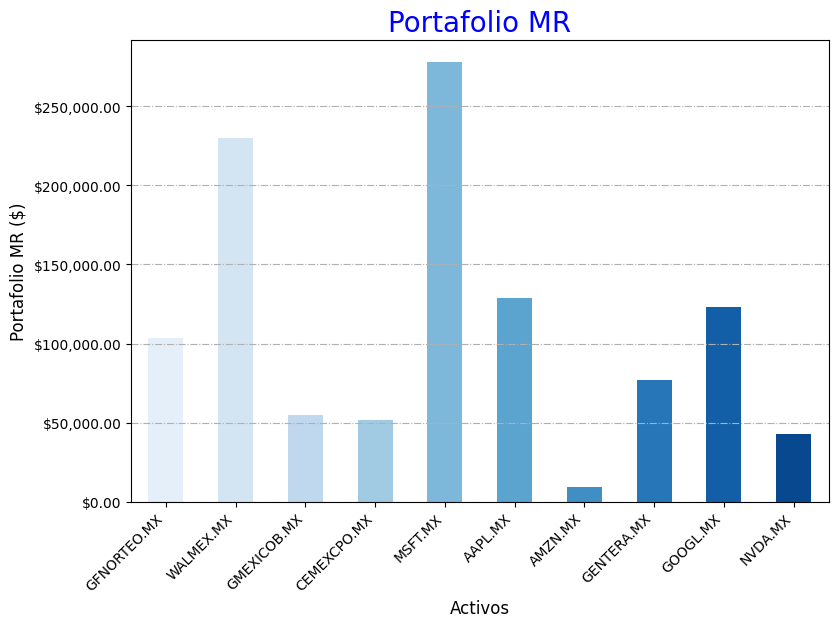

In [112]:
# inf tabla a graficar ---> si funciona y sin .T

print(df_comparativo_activos.columns)

grafica = df_comparativo_activos                # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 3 # 3 es el de mínimo Riesgo

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]


# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"

if pd.api.types.is_string_dtype(data_activos):
# Verifica si el tipo de datos de una Serie o DF es o se puede interpretar como una cadena de texto (string)

    if "%" in data_activos.iloc[0]:  # Verifica si el primer elemento contiene "%"
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)  # Elimina el símbolo "%" y convierte a float
        yLabel_unit = " (%)"  # Asigna el símbolo de porcentaje a la variable de etiqueta
    elif "$" in data_activos.iloc[0]:  # Verifica si el primer elemento contiene "$"
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)  # Elimina el símbolo "$", elimina las comas y convierte a float
        yLabel_unit = " ($)"  # Asigna el símbolo de dólar a la variable de etiqueta
        
# La función del código anterior es detectar si s porcentaje o moneda (en formato string)     
# Limpiamos dichos datso (quitamos "$", "," y "%") para graficarlos
# establecemos la unidad del eje Y   
                   
else: 
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Generamos 3 números aleatorios
#random_color = np.random.rand(3)    # ---> valore RGB

#Creamos una figura y definimos el tamaño
plt.figure(figsize=(9, 6))

#Crea el gráfico con los datos correspondientes
# Generar paleta de colores dinámica basada en el número de elementos
n_colores = len(data_grafico_activos)
# sns.color_palette --> función de Seaborn para generar una paleta de colores 
colores = sns.color_palette("Blues", n_colores)


#Crea el gráfico con los datos correspondientes
# kind = "bar" --> tipo de gráfico (en este caso de barras)
data_grafico_activos.plot(kind='bar', color=colores)

# Agregamos el título del gráfico, cambiamos el tamaño de letra y su color
plt.title(f"{columna_a_graficar_nombre}", fontsize=20, color = 'Blue')      # ---> Modificamos texto

# Establece la etiqueta del eje X
plt.xlabel("Activos", fontsize=12, color = 'black')  #---> Modificamos el texto

# Establece la etiqueta del eje Y
plt.ylabel(columna_a_graficar_nombre + yLabel_unit, fontsize = 12)  # Etiqueta del eje Y

# plt.xticks(rotation = 45, ha = "right") --> Rota las etiquetas del eje X 
# rotation = 45 --> Rota las etiquetas 45 grados
# ha = "right" --> Alinea las etiquetas a la derecha
plt.xticks(rotation = 45, ha = "right")

# plt.grid ---> añade una cuadricula al grafica
# axis = "y" --> Indica que la cuadrícula se aplicará solo al eje X, Y o ambos (axis = "both")
# linestyle = "-." --> Define el estilo de la línea de la cuadrícula (puede ser "-", "--", "-.", ":")
plt.grid(axis='y', linestyle='-.')  # Agrega una cuadrícula horizontal al gráfico

# Obtenemos los ejes (X) actuales
ax = plt.gca()
# formato porcentaje
if " (%)" in yLabel_unit:
    format = mticker.StrMethodFormatter("{x:.2f}%")
# formato moneda
elif " ($)" in yLabel_unit:
    format = mticker.StrMethodFormatter("${x:,.2f}")
# Otro formato (sin símbolo) y separado por miles
else: 
    format = mticker.StrMethodFormatter("{x:,.2f}")

#aplicamos al eje Y
# ax.yaxis --> controla al eje Y de nuestra gráfica
# set_major_formatter --> establece el formato de los valores del eje Y utilizando el formateador definido
# format --> es el formateador que hemos definido anteriormente para dar formato a los valores del eje Y
ax.yaxis.set_major_formatter(format)
plt.show()



## Valuación general de los Activos en los portafolios óptimos

Index(['Posición del portafolio', 'Valuación del portafolio',
       'Esperanza del portafolio', 'Riesgo del portafolio'],
      dtype='object')


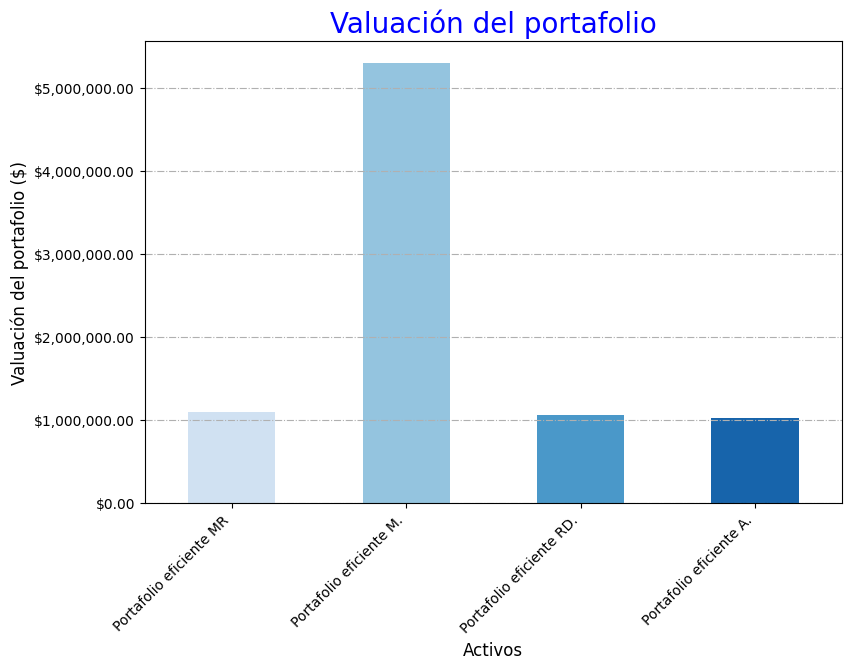

In [113]:
# inf a graficar (mostramos el nombre de las columnas para seleccionar la que queremos graficar)

print(df_comparativo_port.T.columns)

# No funciona sin .T 
grafica = df_comparativo_port.T                # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 1

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]


# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"

if pd.api.types.is_string_dtype(data_activos):
# Verifica si el tipo de datos de una Serie o DF es o se puede interpretar como una cadena de texto (string)

    if "%" in data_activos.iloc[0]:  # Verifica si el primer elemento contiene "%"
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)  # Elimina el símbolo "%" y convierte a float
        yLabel_unit = " (%)"  # Asigna el símbolo de porcentaje a la variable de etiqueta
    elif "$" in data_activos.iloc[0]:  # Verifica si el primer elemento contiene "$"
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)  # Elimina el símbolo "$", elimina las comas y convierte a float
        yLabel_unit = " ($)"  # Asigna el símbolo de dólar a la variable de etiqueta
        
# La función del código anterior es detectar si s porcentaje o moneda (en formato string)     
# Limpiamos dichos datso (quitamos "$", "," y "%") para graficarlos
# establecemos la unidad del eje Y   
                   
else: 
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Generamos 3 números aleatorios
#random_color = np.random.rand(3)    # ---> valore RGB

#Creamos una figura y definimos el tamaño
plt.figure(figsize=(9, 6))

#Crea el gráfico con los datos correspondientes
# Generar paleta de colores dinámica basada en el número de elementos
n_colores = len(data_grafico_activos)
# sns.color_palette --> función de Seaborn para generar una paleta de colores 
colores = sns.color_palette("Blues", n_colores)


#Crea el gráfico con los datos correspondientes
# kind = "bar" --> tipo de gráfico (en este caso de barras)
data_grafico_activos.plot(kind='bar', color=colores)

# Agregamos el título del gráfico, cambiamos el tamaño de letra y su color
plt.title(f"{columna_a_graficar_nombre}", fontsize=20, color = 'Blue')      # ---> Modificamos texto

# Establece la etiqueta del eje X
plt.xlabel("Activos", fontsize=12, color = 'black')  #---> Modificamos el texto

# Establece la etiqueta del eje Y
plt.ylabel(columna_a_graficar_nombre + yLabel_unit, fontsize = 12)  # Etiqueta del eje Y

# plt.xticks(rotation = 45, ha = "right") --> Rota las etiquetas del eje X 
# rotation = 45 --> Rota las etiquetas 45 grados
# ha = "right" --> Alinea las etiquetas a la derecha
plt.xticks(rotation = 45, ha = "right")

# plt.grid ---> añade una cuadricula al grafica
# axis = "y" --> Indica que la cuadrícula se aplicará solo al eje X, Y o ambos (axis = "both")
# linestyle = "-." --> Define el estilo de la línea de la cuadrícula (puede ser "-", "--", "-.", ":")
plt.grid(axis='y', linestyle='-.')  # Agrega una cuadrícula horizontal al gráfico

# Obtenemos los ejes (X) actuales
ax = plt.gca()
# formato porcentaje
if " (%)" in yLabel_unit:
    format = mticker.StrMethodFormatter("{x:.2f}%")
# formato moneda
elif " ($)" in yLabel_unit:
    format = mticker.StrMethodFormatter("${x:,.2f}")
# Otro formato (sin símbolo) y separado por miles
else: 
    format = mticker.StrMethodFormatter("{x:,.2f}")

#aplicamos al eje Y
# ax.yaxis --> controla al eje Y de nuestra gráfica
# set_major_formatter --> establece el formato de los valores del eje Y utilizando el formateador definido
# format --> es el formateador que hemos definido anteriormente para dar formato a los valores del eje Y
ax.yaxis.set_major_formatter(format)
plt.show()



## Histograma y densidad

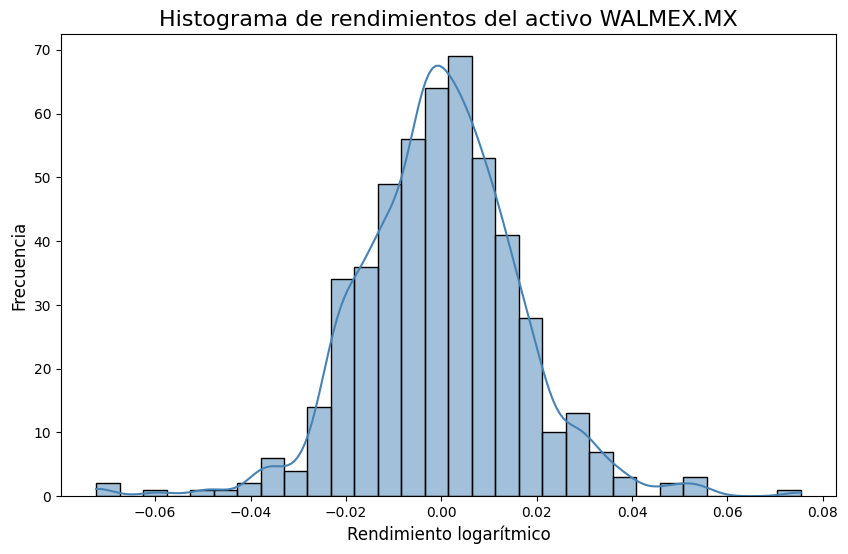

In [114]:
# selc nestro activo a graficar
a = 1

# nombre del activo
nombre_activo = precios.columns[a]

#creamos la figura histograma 
plt.figure(figsize=(10, 6))
# graficamos el histograma de los rendimientos del activo seleccionado
sns.histplot(rendimientos[nombre_activo], bins=30, kde=True, color='steelblue',
             label = "Histograma y Densidad",
             kde_kws={'bw_adjust': 0.7})  # Ajuste del ancho de banda para la curva KDE

# Añadimos etiquetas y título
plt.title(f"Histograma de rendimientos del activo {nombre_activo}", fontsize=16)
plt.xlabel("Rendimiento logarítmico", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
# Mostramos el gráfico
plt.show()


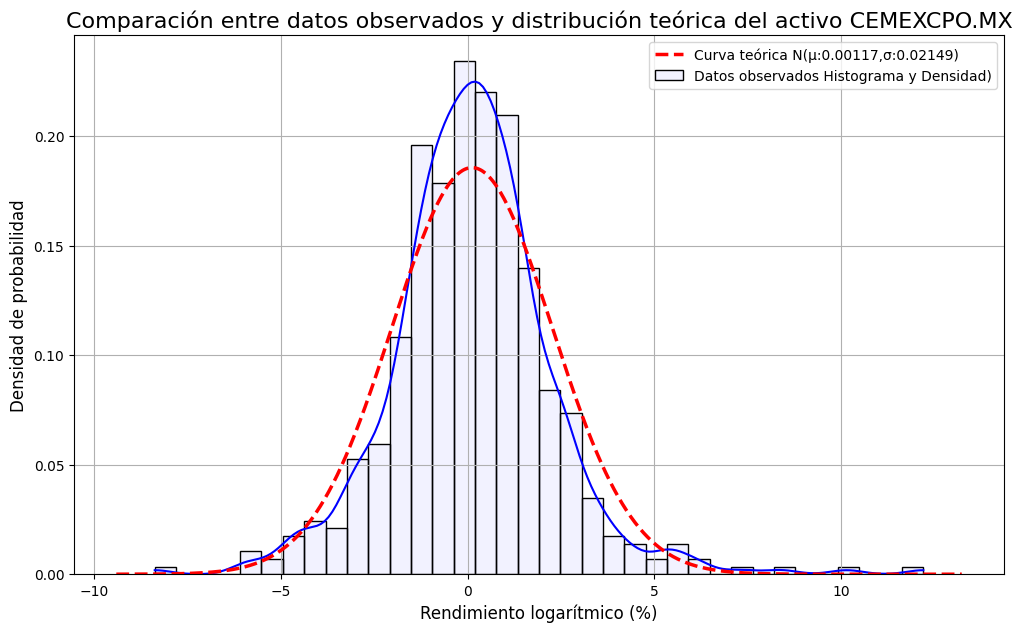

In [115]:
# seleccionamso nuestro activo a graficar

a = 3
nombre_activo = precios.columns[a]

# información teórica
# obtenemos la media mu y desv estandar (sigma) de nuestro activo

mu_teorica = esperanza_activos.iloc[a]
sigma_teorica = riesgo_activos.iloc[a]

# creamos nuestro gráfico base (el graf anterior)// tamaño de gráfico
plt.figure(figsize=(12, 7))

# añadimos la info real para nuestroo histograma y densidad 
# recordar mult por 100 para convertir a porcentaje
# graficamos la columna de rendimientros del activo seleccionado

sns.histplot(rendimientos.iloc[:,a]*100,
             kde=True,  # Agrega la curva de densidad KDE al histograma
             stat="density",  # Normaliza el histograma para mostrar la densidad de probabilidad
             color='blue',  # Color del histograma
             label = "Datos observados Histograma y Densidad)",  # Etiqueta para la leyenda
             kde_kws={'bw_adjust': 0.7},  # Ajuste del ancho de banda para la curva KDE
             alpha=0.05  # Ajuste de la transparencia del histograma (va de 0 a 1)
             )
# Añadimos la info teórica al gráfico
# definimos le rango de la curva teorica basado en nuestro gráfico anterior
# Hacemos que nuestra gráfica N(,) tenga el mismo rango que nuestros datos reales

# plt.xlim() --> función de Matplotlib que devuelve los límites actuales del eje X de un gráfico.
x_min, x_max = plt.xlim()  # Obtiene los límites actuales del eje X del gráfico
x_teorica = np.linspace(x_min, x_max, 1000)  # Genera 1000 puntos equidistantes entre los límites del eje X para la curva teórica

# Calculamos la función de densidad de probabilidad (PDF) de la distribución normal utilizando los parámetros teóricos (mu y sigma)
# importante también mult por 100 para convertir a porcentaje

y_teorico = norm.pdf(x_teorica,
                     loc = mu_teorica*100,  # Media de la distribución normal (convertida a porcentaje)
                     scale = sigma_teorica*100  # Desviación estándar de la distribución normal (convertida a porcentaje)
                     )

# Graficamos la curva teórica en el mismo gráfico
plt.plot(
    x_teorica,  # Eje X para la curva teórica
    y_teorico,  # Eje Y para la curva teórica
    color='red',  # Color de la curva teórica
    linestyle='--',  # Estilo de línea para la curva teórica (en este caso, línea discontinua)
    linewidth=2.5,  # Ancho de la línea para la curva teórica
    label = f"Curva teórica N(μ:{mu_teorica:.5f},σ:{sigma_teorica:.5f})"  # Etiqueta para la leyenda de la curva teórica
    )

# formato a la gráfica 

plt.title(f"Comparación entre datos observados y distribución teórica del activo {nombre_activo}", fontsize=16)
plt.xlabel("Rendimiento logarítmico (%)", fontsize=12)
plt.ylabel("Densidad de probabilidad", fontsize=12)
plt.grid()  # Agrega una cuadrícula al gráfico
plt.legend()  # Muestra la leyenda del gráfico


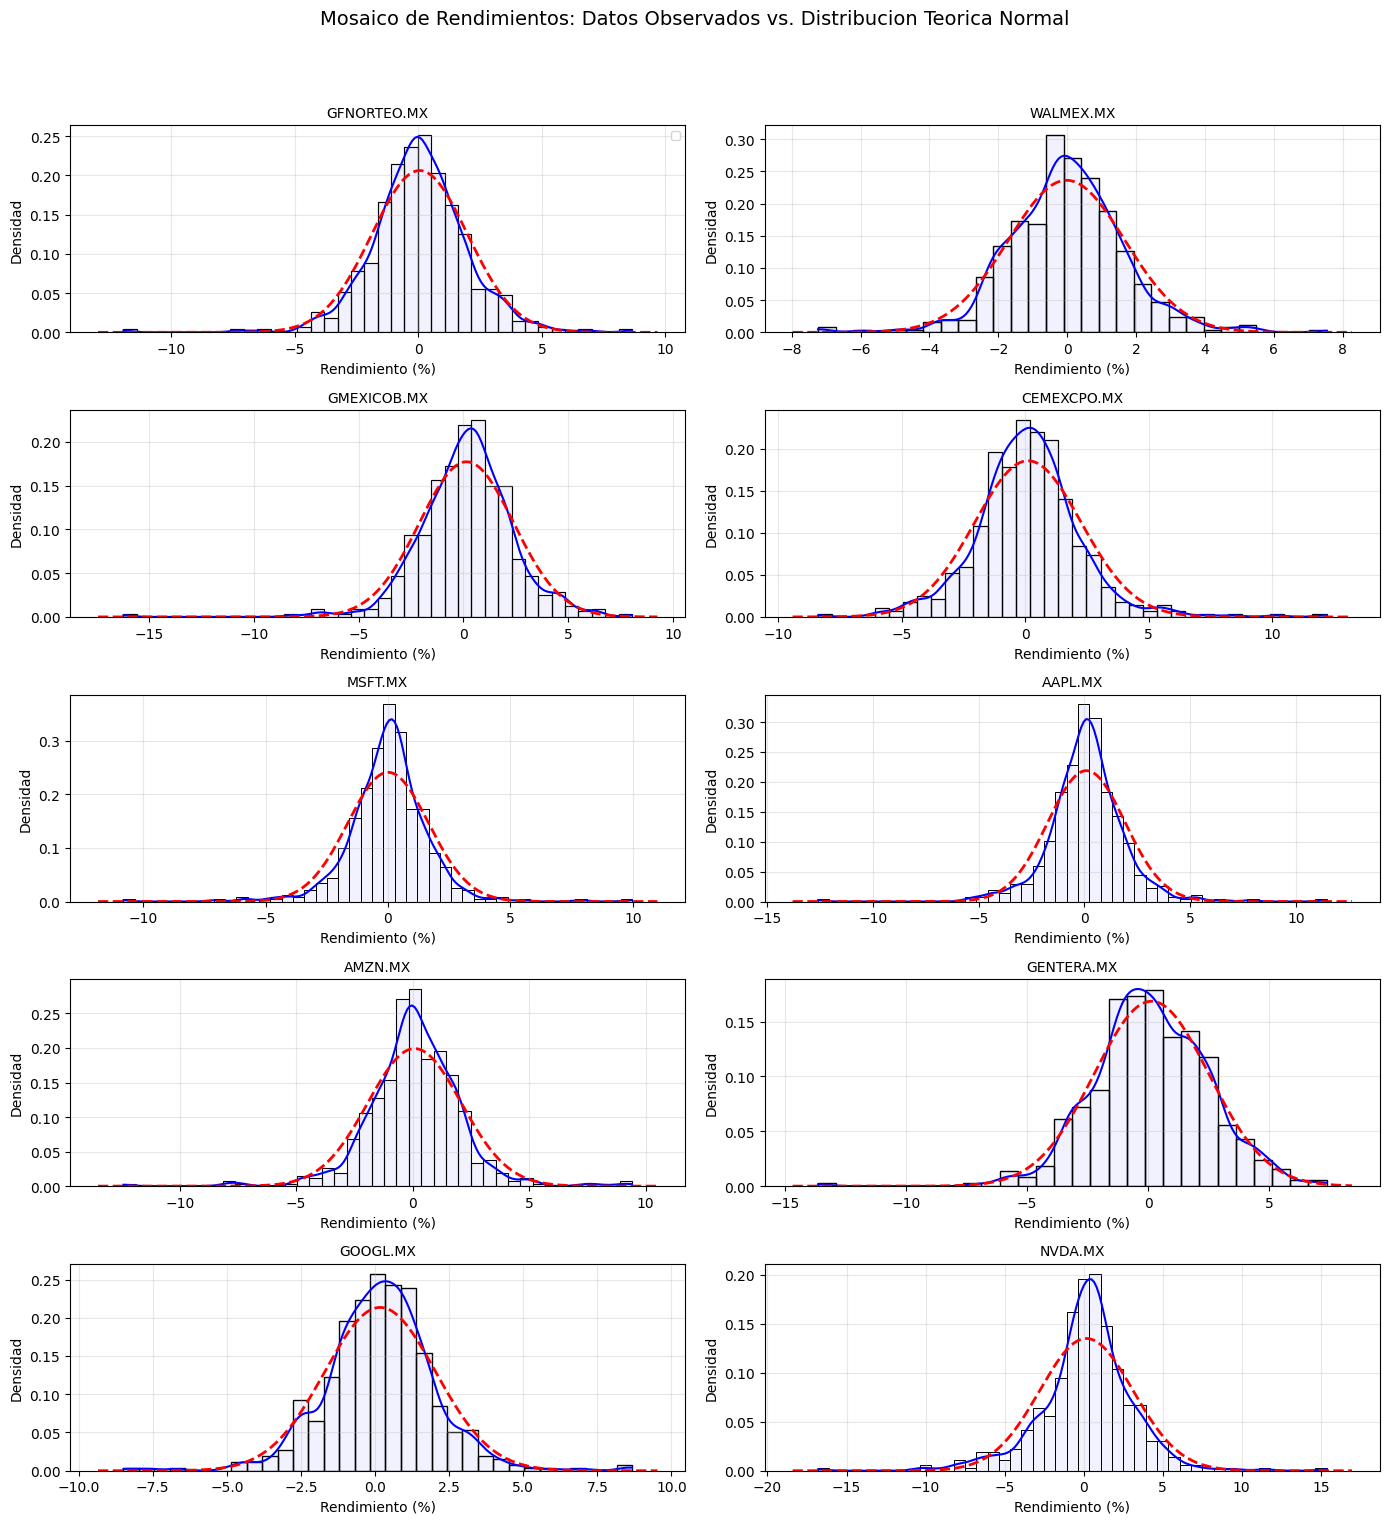

In [116]:
# Mosaico con matplotlib
rows = int(np.ceil(len(precios.columns) / 2))
cols = 2

fig_mosaico, axes = plt.subplots(
    rows, cols,
    figsize=(14, 3.2 * rows),
    sharex=False, sharey=False
 )
axes = np.array(axes).reshape(-1)

for i, col in enumerate(precios.columns):
    ax = axes[i]
    returns_pct = rendimientos[col] * 100
    
    mu_teorica = esperanza_activos.loc[col]
    sigma_teorica = riesgo_activos.loc[col]
    
    sns.histplot(
        returns_pct,
        kde=True,
        stat="density",
        color="blue",
        kde_kws={"bw_adjust": 0.7},
        alpha=0.05,
        ax=ax
    )
    
    x_min, x_max = ax.get_xlim()
    x_teorica = np.linspace(x_min, x_max, 1000)
    y_teorico = norm.pdf(x_teorica, loc=mu_teorica * 100, scale=sigma_teorica * 100)
    ax.plot(
        x_teorica,
        y_teorico,
        color="red",
        linestyle="--",
        linewidth=2.0,
    )
    
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Rendimiento (%)")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(len(precios.columns), len(axes)):
    axes[j].axis("off")

fig_mosaico.suptitle(
    "Mosaico de Rendimientos: Datos Observados vs. Distribucion Teorica Normal",
    fontsize=14
 )
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [117]:
# Guardamos el mosaico como imagen estatica PNG en el folder 'prueba'
fig_mosaico.savefig("prueba/distribucion_activos.png", dpi=300, bbox_inches="tight")

## Correlación

In [118]:
# Correlación 
# ---> si una corr es positiva, significa que ambas variables tienden a moverse en la misma dirección (cuando una aumenta, la otra también tiende a aumentar).
###### si un activo A baja entonces el activo B también baja
###### si un activo A sube entonces el activo B también sube

# ---> si una corr es negativa, significa que ambas variables tienden a moverse en direcciones opuestas (cuando una aumenta, la otra tiende a disminuir).
###### si un activo A baja entonces el activo B sube
###### si un activo A sube entonces el activo B baja

# ---> si una corr es 1 entonces "son la misma"
# ---> si una corr es 0 entonces "no tienen relación" o es muy debil 

# Gráfico de calor para visualizar la matriz de correlación
""" 
rendimientos_corr = rendimientos.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(rendimientos_corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Matriz de Correlación de Rendimientos", fontsize=16) 
plt.show()

 """

' \nrendimientos_corr = rendimientos.corr()\n\nplt.figure(figsize=(10, 8))\nsns.heatmap(rendimientos_corr, annot=True, cmap=\'coolwarm\', fmt=".3f", linewidths=0.5)\nplt.title("Matriz de Correlación de Rendimientos", fontsize=16) \nplt.show()\n\n '

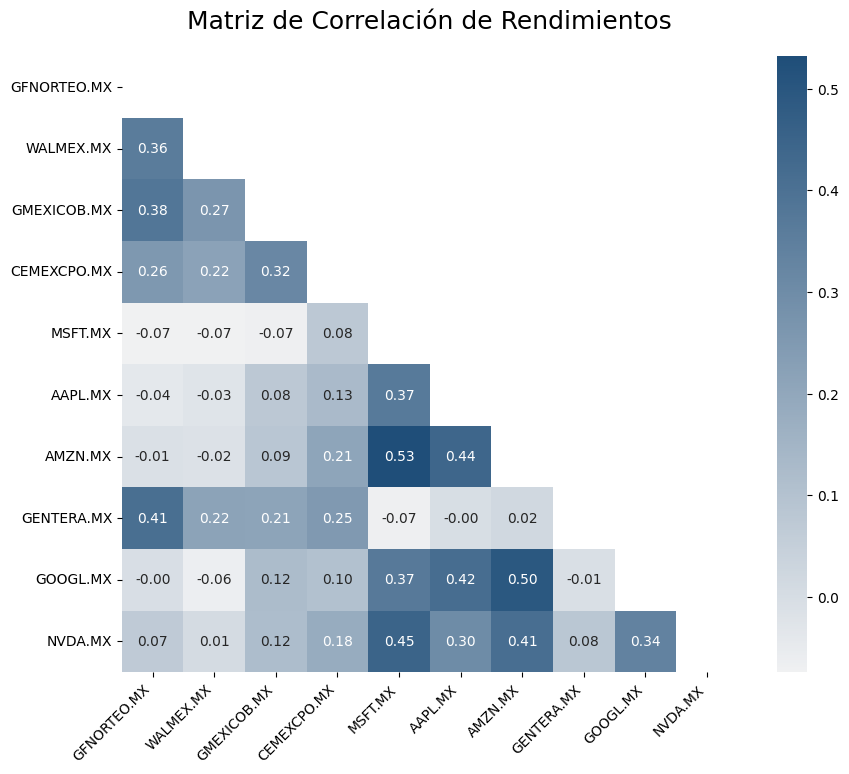

In [119]:
# calculamos la matriz de correlación

rendimientos_corr = rendimientos.corr()

# Vamos a filtrar los datos con una mascara 
# np.ones_like --> Crea una matriz del mismo tamaño de rendimiento_corr
# dtype = bool --> La matriz creada tendrá valores booleanos (True/False)
# np.triu --> Convierte los valores inferiores a la diagonal superior en Falso
mask = np.triu(np.ones_like(rendimientos_corr, dtype=bool))

# Paleta azul mas profesional
cmap_prof = sns.light_palette("#1f4e79", as_cmap=True)

# graficamos 
plt.figure(figsize=(10, 8))
sns.heatmap(rendimientos_corr,
            mask = mask,  # Aplica la máscara para ocultar los valores inferiores a la diagonal
            annot = True,  # Muestra los valores de correlación en cada celda
            cmap = cmap_prof, # Colores para la escala de correlación
            cbar=True,       # Colores para la escala de correlación 
            fmt=".2f",       # Formato de los valores de correlación (2 decimales)
            square=True,    # Hace que las celdas sean cuadradas  
            annot_kws={"size": 10}  # Tamaño de la fuente de los valores de correlación
            )
# Título del gráfico
# (pad) entre el título y el gráfico
plt.title("Matriz de Correlación de Rendimientos", fontsize=18, pad=20)  # Título del gráfico con un espacio adicional 

# ejes

plt.xticks(rotation=45, ha="right")  # Rota las etiquetas del eje X 45 grados y las alinea a la derecha (si es left entonces se alinea a la izquierda)
plt.yticks(rotation=0)  # Mantiene las etiquetas del eje Y sin rotar
plt.show()


# Estadísticas rápidas

In [120]:
# Estadísticas rápidas

estadisticas_rapidas = rendimientos.describe().T

estadisticas_rapidas

,count,mean,std,min,25%,50%,75%,max
GFNORTEO.MX,500.0,0.000596,0.019368,-0.119195,-0.010528,0.000170,0.011279,0.086472
WALMEX.MX,500.0,-0.000185,0.016910,-0.072364,-0.010791,-0.000418,0.009812,0.075345
GMEXICOB.MX,500.0,0.001485,0.022527,-0.162391,-0.010995,0.002456,0.014470,0.080525
CEMEXCPO.MX,500.0,0.001168,0.021516,-0.083819,-0.010490,0.000841,0.012539,0.122037
MSFT.MX,500.0,0.000060,0.016550,-0.108052,-0.007821,0.000552,0.008040,0.099680
AAPL.MX,500.0,0.000950,0.018253,-0.125867,-0.008203,0.000772,0.009722,0.114443
AMZN.MX,500.0,0.000807,0.020060,-0.124179,-0.009639,0.000769,0.011648,0.094179
GENTERA.MX,500.0,0.001360,0.023705,-0.136315,-0.012907,0.000000,0.017226,0.073646
GOOGL.MX,500.0,0.001730,0.018707,-0.084880,-0.008770,0.002014,0.012165,0.086697
NVDA.MX,500.0,0.001702,0.029561,-0.168037,-0.011001,0.003023,0.016675,0.153673


# Estadísticas y pruebas

In [121]:
# Cálculo de métricas  

skewness = rendimientos.skew()  # Asimetría de los datos
kurtosis = rendimientos.kurtosis()  # Curtosis de los datos

# Creamos las funciones para su interpretación

def interpretar_skewness(s):
    if s > 0:
        return f"{s:4f} CLD, Subidas bruscas" # (tendencia a subidas fuertes)
    elif s < 0: 
        return f"{s:4f} CLI, Caidas bruscas, VaR más alto " # (tendencia a caidas fuertes VaR más alto) 
    else:
        return "Distribución normal"
def interpretar_kurtosis(k):
    if k < 0:
        # Baja concentración de los datos al rededor de la media
        # Menos riesgo en las colas
        return f"{k:4f} Platicúrtica (colas menos largas)"    
    elif k > 0:
        # Alta concentración de los datos al rededor de la media
        # Más riesgo en las colas
        return f"{k:4f} Leptocúrtica (colas más largas)"
    else:
        return f"{k:4f} Mesocúrtica Distribución normal"
    
# dataframe del diagnóstico
analalisis_estadistico = pd.DataFrame({
                                      "Skewness": skewness.apply(interpretar_skewness),
                                      "Kurtosis": kurtosis.apply(interpretar_kurtosis)
                                      })
analalisis_estadistico

,Skewness,Kurtosis
GFNORTEO.MX,"-0.262767 CLI, Caidas bruscas, VaR más alto",3.933727 Leptocúrtica (colas más largas)
WALMEX.MX,"-0.003370 CLI, Caidas bruscas, VaR más alto",2.189750 Leptocúrtica (colas más largas)
GMEXICOB.MX,"-0.787441 CLI, Caidas bruscas, VaR más alto",6.053021 Leptocúrtica (colas más largas)
CEMEXCPO.MX,"0.563036 CLD, Subidas bruscas",3.673361 Leptocúrtica (colas más largas)
MSFT.MX,"-0.244162 CLI, Caidas bruscas, VaR más alto",7.860934 Leptocúrtica (colas más largas)
AAPL.MX,"-0.087146 CLI, Caidas bruscas, VaR más alto",8.252687 Leptocúrtica (colas más largas)
AMZN.MX,"-0.281667 CLI, Caidas bruscas, VaR más alto",5.649128 Leptocúrtica (colas más largas)
GENTERA.MX,"-0.299323 CLI, Caidas bruscas, VaR más alto",2.017534 Leptocúrtica (colas más largas)
GOOGL.MX,"0.019695 CLD, Subidas bruscas",3.101696 Leptocúrtica (colas más largas)
NVDA.MX,"-0.390817 CLI, Caidas bruscas, VaR más alto",4.338818 Leptocúrtica (colas más largas)


In [122]:
# Prueba JB

# definimos una funcion para la prueba JB y extraer los resultados

def prueba_jarque_bera(datos):
    # Estadístico y p-valor de la prueba JB
    jb_stat, p_value = stats.jarque_bera(datos)
    
    # Interpretación del resultado a un nivel de confianza del 95% (alpha = 0.05)

    decision = "Rechaza Normalidad" if p_value < 0.05 else "No Rechaza Normalidad"
    
    return pd.Series([jb_stat, p_value, decision],
                     index=["Estadístico JB", "P-value", "Decisión"])
    
# aplicamos la función a cada columna de rendimientos
tabla_jb = rendimientos.apply(prueba_jarque_bera) 
tabla_jb.T

,Estadístico JB,P-value,Decisión
GFNORTEO.MX,319.760779,0.0,Rechaza Normalidad
WALMEX.MX,96.8357,0.0,Rechaza Normalidad
GMEXICOB.MX,796.540941,0.0,Rechaza Normalidad
CEMEXCPO.MX,299.98496,0.0,Rechaza Normalidad
MSFT.MX,1262.890747,0.0,Rechaza Normalidad
AAPL.MX,1387.290243,0.0,Rechaza Normalidad
AMZN.MX,655.437107,0.0,Rechaza Normalidad
GENTERA.MX,89.545762,0.0,Rechaza Normalidad
GOOGL.MX,194.95291,0.0,Rechaza Normalidad
NVDA.MX,394.922908,0.0,Rechaza Normalidad


In [123]:
# creamos un reporte de los rendimientos

"""
profile = ProfileReport(rendimientos,
                        title="Reporte de Rendimientos",
                        correlations = {"pearson": {"calculate": True}}
                        )
# exportamos el archivo en formato HTML
profile.to_file("reporte_rendimientos.html")
"""

'\nprofile = ProfileReport(rendimientos,\n                        title="Reporte de Rendimientos",\n                        correlations = {"pearson": {"calculate": True}}\n                        )\n# exportamos el archivo en formato HTML\nprofile.to_file("reporte_rendimientos.html")\n'

# Densidad acumulada

In [124]:
# Obtenemos los rend del activo seleccionado

rend_activo = rendimientos.iloc[:,a].sort_values()

# calculamos la frec
freq = np.arange(1, len(rend_activo)+1) / len(rend_activo)

# graficamos

fig = go.Figure()

fig.add_trace(go.Scatter(
    x = rend_activo*100,  # Eje X con los rendimientos ordenados del activo seleccionado
    y = freq*100,  # Eje Y con las frecuencias acumuladas correspondientes a cada rendimiento
    mode = 'lines',  # Modo de visualización (líneas)
    name = f"ECDF del activo {nombre_activo}",  # Nombre para la leyenda
    line = dict(color = 'steelblue'),  # Color de la línea del gráfico
))

In [125]:
# _______________________ Datos Reales__________________________

# Obtenemos los rend del activo seleccionado ---> a = n
#.sort_values() --> ordena los valores de la Serie de menor a mayor
# mult por 100 para tener la escla igual
# np.arange(1, len(rend_activo_ptc)+1) ---> creameos un arreglo con numeros desde 1
# hasta el total de rendimientos incluido el último (len(rend_activo_ptc)+1) para que el último número sea igual al total de rendimientos
# Dividimos enre el total para calcular nuestra frec relativa (proba)


rend_activo_ptc = rendimientos.iloc[:,a].sort_values() * 100

freq_real = np.arange(1, len(rend_activo_ptc)+1) / len(rend_activo_ptc)

# _______________________Normal Teórica_________________________

# añadimos los parametros de nuestra grafica N(mu, sigma)
mu = esperanza_activos.iloc[a] * 100
sigma = riesgo_activos.iloc[a] * 100

# definimos el rango X basado en los datos rerales (que coincidan)
# creamos una secuencia de num separados de manera unif
# definimos el rangfo inicial con .min()
# definimos el rango final con .max()
# especificamos el num de puntos que se generan

x = np.linspace(rend_activo_ptc.min(), rend_activo_ptc.max(), 1000)

# Calculamos las curvas teoricas
# norm.pdf --> función de densidad de probabilidad de la distribución normal
# norm.cdf --> función de distribución acumulada de la distribución normal
# mult por 100 norm.cdf para que su prob sea en porcentaje y coincida con la escala de los datos reales
y_pdf = norm.pdf(x, loc=mu, scale=sigma) *100 # PDF de la distribución normal con media mu y desviación estándar sigma
y_cdf = norm.cdf(x, loc=mu, scale=sigma) *100  # CDF de la distribución normal con media mu y desviación estándar sigma

# configuramos los formatos a utilizar en el gráfico

mi_hover = "%{y:2f}"
mi_hover_percent = "%{y:.2f}%"

# Creamos una gráfica con un eje Y secundario para mostrar tanto la PDF como la CDF en el mismo gráfico
# specs = [[{"secondary_y": True}]] --> Especifica que el gráfico tendrá un eje Y secundario en la primera
# fila y primera columna del diseño de subgráficos (subplot)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# PDF Teórica (Densidad)
fig.add_trace(go.Scatter(
    x = x,  # Eje X con los valores de rendimiento para la curva teórica
    y = y_pdf,  # Eje Y con los valores de la PDF de la distribución normal
    mode = 'lines',  # Modo de visualización (líneas)
    name = f"Densidad Teórica (N({mu:.2f}, {sigma:.2f}))",  # Nombre para la leyenda
    line = dict(color = 'blue', width=2),  # Color y estilo de línea para la PDF teórica
    fill = 'tozeroy',  # Rellena el área bajo la curva de la PDF
    fillcolor = 'rgba(65, 105, 225, 0.05)',  # Color de relleno para el área bajo la curva de la PDF (con transparencia)
    hovertemplate = mi_hover  # Formato de la información al pasar el cursor sobre la curva de la PDF
), secondary_y = False)  # secondary_y=False indica que esta traza se asigna al eje Y principal

# CDF Teórica (Función de distribución acumulada)
fig.add_trace(go.Scatter(
    x = x,  # Eje X con los valores de rendimiento para la curva teórica
    y = y_cdf,  # Eje Y con los valores de la CDF de la distribución normal
    mode = 'lines',  # Modo de visualización (líneas)
    name = f"CDF Teórica (N({mu:.2f}, {sigma:.2f}))",  # Nombre para la leyenda
    line = dict(color = 'green', width=2),  # Color y estilo de línea para la CDF teórica
    hovertemplate = mi_hover_percent  # Formato de la información al pasar el cursor sobre la curva de la CDF
), secondary_y = True)  # secondary_y=True indica que esta traza se asigna al eje Y secundario

# Frecuencia acumulada real (ECDF)
fig.add_trace(go.Scatter(
    x = rend_activo_ptc,  # Eje X con los rendimientos ordenados del activo seleccionado
    y = freq_real*100,  # Eje Y con las frecuencias acumuladas correspondientes a cada rendimiento (en porcentaje)
    mode = 'lines',  #    Modo de visualización (marcadores)
    name = f"ECDF Real del activo {nombre_activo}",  # Nombre para la leyenda
    marker = dict(color = 'red', size=6),  # Color y tamaño de los marcadores para la ECDF real
    hovertemplate = mi_hover_percent  # Formato de la información al pasar el cursor sobre los puntos de la ECDF real
), secondary_y = True)  # secondary_y=True indica que esta traza se asigna al eje Y secundario

# Diseño del gráfico y de nuestros ejes
fig.update_layout(
    # <b> </b> --> etiqueta HTML para poner en negritas el texto del título
    # <br> --> etiqueta HTML para hacer un salto de línea en el título
    # <sup> </sup> --> etiqueta HTML para poner en superíndice el texto del título
    # <sub> </sub> --> etiqueta HTML para poner en subíndice el texto del título
    title = f"<b>Análisis de Distribución: {nombre_activo}</b><br><sup>Comparación entre datos reales y distribución normal teórica N({mu:.2f}, {sigma:.2f})</sup>",  # Título del gráfico con formato HTML
    title_font_size = 20,  # Tamaño de la fuente del título
    xaxis_title = "Rendimiento logarítmico (%)",  # Etiqueta del eje X
    yaxis_title = "Densidad de probabilidad",  # Etiqueta del eje Y principal
    template = "plotly_dark",  # Diseño del fondo del gráfico
    width = 1000,  # Ancho del gráfico en píxeles
    height = 600,  # Alto del gráfico en píxeles
    hovermode = "x unified",  # Modo de visualización de la información al pasar el cursor sobre el gráfico
    legend = dict(yanchor="top", y=0.99, xanchor="left", x=0.01)  # Posición de la leyenda en la parte superior izquierda del gráfico
    # xanchor --> ancla la posición de la leyenda al eje X (left, center, right)
    # x = 0.01 --> posición horizontal de la leyenda (0.01 es cerca del borde izquierdo, 0.5 es el centro, 0.99 es cerca del borde derecho
    # yanchor --> ancla la posición de la leyenda al eje Y (top, middle, bottom)
    # y = 0.99 --> posición vertical de la leyenda (0.01 es cerca del borde inferior, 0.5 es el centro, 0.99 es cerca del borde superior
    )
# eje Y izq (densidad)
fig.update_yaxes(
    showgrid = True,  # Muestra la cuadrícula en el eje Y
    title_text = "Densidad de probabilidad",  # Etiqueta del eje Y principal
    tickfont = dict(color = "lightblue"),  # Color de los valores del eje Y principal
    secondary_y= False # Indica que esta configuración se aplica al eje Y principal
)

# eje Y derecho (frecuencia acumulada)
fig.update_yaxes(
    showgrid = False,  # No muestra la cuadrícula en el eje Y secundario
    title_text = "Frecuencia acumulada (%)",  # Etiqueta del eje Y secundario
    tickfont = dict(color = "lightgreen"),  # Color de los valores del eje Y secundario
    secondary_y= True # Indica que esta configuración se aplica al eje Y secundario
)

# añadimos las lineas de referencia
fig.add_vline(x=mu, line_dash="dash", line_color="cyan", annotation_text=f"Media (μ): {mu:.2f}%", annotation_position="top left")
fig.add_hline(y = 50, line_width=1, line_dash="dash", line_color="gray", secondary_y=True)
fig.add_vline(x=mu+sigma, line_dash="dot", line_color="orange", annotation_text=f"μ + σ: {(mu+sigma):.2f}%", annotation_position="bottom left")
fig.add_vline(x=mu-sigma, line_dash="dot", line_color="orange", annotation_text=f"μ - σ: {(mu-sigma):.2f}%", annotation_position="bottom right")



#añadimos valores atípicos
fig.add_vline(x = limite_inferior[a]*100, line_width=1, line_dash="dash", line_color="purple", annotation_text=f"Limite inferior (Outliers): {limite_inferior[nombre_activo]*100:.2f}%", annotation_position="top left")
fig.add_vline(x = limite_superior[a]*100, line_width=1, line_dash="dash", line_color="purple", annotation_text=f"Limite superior (Outliers): {limite_superior[nombre_activo]*100:.2f}%", annotation_position="top right")

fig.show()


# Valores atípicos

In [126]:
# valores atípicos

# son puntos que difieren sustancialmente de los demás

# 1) datos < Q1 - 1.5 * IQR
# 2) datos > Q3 + 1.5 * IQR

# IQR ---> rango intercuantilico
# medida de dispersion, la distancia entre el percentil 25 y el 75

# Calculamos los componentes necesarios
Q1 = rendimientos.quantile(0.25)
Q3 = rendimientos.quantile(0.75)
IQR = Q3 - Q1

# Definimos los límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificamos nuestros valores atípicos
outliers_mas_bajos = rendimientos < limite_inferior
outliers_mas_altos = rendimientos > limite_superior

# "combinamos" nuestras tablas anteriores de valores atípicos
# operador lógico OR |
# TRUE OR TRUE ---> TRUE
# TRUE OR FALSE ---> TRUE
todos_los_outliers = outliers_mas_bajos | outliers_mas_altos

# Agrupamos los datos
conteo_outliers = pd.DataFrame({
    "Atípicos Inferiores": outliers_mas_bajos.sum(),
    "% Atípicos Inferiores": (outliers_mas_bajos.sum() / len(rendimientos) * 100).map("{:.2f}%".format),
    "Atípicos Superiores": outliers_mas_altos.sum(),
    "% Atípicos Superiores": (outliers_mas_altos.sum() / len(rendimientos) * 100).map("{:.2f}%".format),
    "Total Atípicos": todos_los_outliers.sum(),
    "% Total Atípicos": (todos_los_outliers.sum() / len(rendimientos) * 100).map("{:.2f}%".format)
})

conteo_outliers

,Atípicos Inferiores,% Atípicos Inferiores,Atípicos Superiores,% Atípicos Superiores,Total Atípicos,% Total Atípicos
GFNORTEO.MX,6,1.20%,9,1.80%,15,3.00%
WALMEX.MX,5,1.00%,6,1.20%,11,2.20%
GMEXICOB.MX,9,1.80%,6,1.20%,15,3.00%
CEMEXCPO.MX,11,2.20%,12,2.40%,23,4.60%
MSFT.MX,12,2.40%,9,1.80%,21,4.20%
AAPL.MX,14,2.80%,11,2.20%,25,5.00%
AMZN.MX,11,2.20%,10,2.00%,21,4.20%
GENTERA.MX,4,0.80%,3,0.60%,7,1.40%
GOOGL.MX,9,1.80%,7,1.40%,16,3.20%
NVDA.MX,23,4.60%,8,1.60%,31,6.20%


In [127]:
# 

# Simulación de portafolios

$$
\mathbb{E}(R_p) = \left( \frac{\mathbb{E}(R_m) - R_f}{\sigma_m}        \right) \sigma_p + R_f \\
f(x) = mx + b
$$

In [128]:
# Simulación de portafolios

# numero de simulacions
n_simulaciones = 10000


# generamos nuestros pesos aleatorios
# random.uniform --> función de NumPy que genera números aleatorios siguiendo una distribución uniforme en un rango especificado
# -1, 1 --> rango de los números aleatorios generados (en este caso, entre -1 y 1)
# size=(n_simulaciones, len(precios.columns)) --> especifica la forma de la matriz de pesos aleatorios, donde n_simulaciones es el número de filas (simulaciones) y len(precios.columns) es el número de columnas

pesos_aleatorios = np.random.uniform(-1,1, size=(n_simulaciones, num_columnas)) # Genera una matriz de pesos aleatorios entre -1 y 1 con dimensiones (n_simulaciones, número de activos)

# Estandarizamos para que la suma de 1
# np.sum(pesos_aleatorios, axis = 1) ---> Calcula la suma de los pesos aleatorios a lo largo de las filas (axis=1)
# pesos aletorios ---> 10k filas, 10 columnas
# pesos_aleatorios.T ---> 10 filas, 10k columna
# Para llevarlo al arreglo original de 10k filas y 10 columnas, se vuelve a transponer con .T al final
pesos_finales = (pesos_aleatorios.T / np.sum((pesos_aleatorios), axis=1)).T

# Obtenemos los parametros calculados
MVCV = matriz_var_principal
RI = esperanza_activos

# creamos una lista vacía para el cálculo
# calculamos el riesgo y los rendimientos

VARs_sim = []
RENs_sim = []

for W in pesos_finales:
    # Cálculo del rendimientoS con los pesos sim y anualizamos
    rendimiento = (W @ RI) * 252 # Rendimiento anualizado del portafolio simulado
    # Calculo del riesgo con los pesos sim y anualizamos
    volatilidad = np.sqrt(W @ MVCV @ W * 252)  # Volatilidad anualizada del portafolio simulado
    
    #agregamos a la lista
    VARs_sim.append(volatilidad)
    RENs_sim.append(rendimiento)

var_rf = 0
ren_rf = tasa_cetes*252*100

# aquí ponen la inf del port MR
var_MR = riesgo_port_MR * np.sqrt(252) * 100
ren = esp_port_MR * 252 * 100

var_M = riesgo_port_M * np.sqrt(252) * 100
ren_M = esp_port_M * 252 * 100

var_RD = riesgo_port_RD * np.sqrt(252) * 100
ren_RD = esp_port_RD * 252 * 100

var_A = riesgo_port_A * np.sqrt(252) * 100
ren_A = esp_port_A * 252 * 100

dt_Tasas = pd.DataFrame({"Riesgo": VARs_sim, "Retorno": RENs_sim})

In [129]:
import plotly.express as px

# --- Construcción de la gráfica ---

# filtramos los datos de nuestro portafolio /// ponemos un límite
# obrenemos los valores de DT_Tasas que cumplen con la condición de riesgo menor a  1 /// 100%

df_filtrado = 100 * dt_Tasas[dt_Tasas["Riesgo"] <= 1]

# Paleta de colores profesional
color_sim = "#6b86a4"
color_frontier = "#1f4e79"
color_lmc = "#4f8fb3"
color_rf = "#2f7d68"
color_mr = "#3b6ea5"
color_m = "#a04a4a"
color_rd = "#b08a3b"
color_a = "#6b4e8a"

# creamos la gráfica

fig_port_ef = px.scatter(df_filtrado, x="Riesgo", y="Retorno",
                 title=f"<b>Simulación de Portafolios</b><br><sup>Riesgo vs Retorno de {n_simulaciones} portafolios simulados</sup>",
                 color_discrete_sequence=[color_sim],
                 opacity=0.35,
                 )

# hacemos más tenues los puntos simulados
fig_port_ef.update_traces(marker=dict(size=4), selector=dict(mode="markers"))

# --- Frontera eficiente ---
# creamos una secuencia de números espaciados uniformemente

rend_deseado_range = np.linspace(-0.001, 0.005, 5000)

# Creamos listas facias para almacenar los datos

esperanza_frontera = []
varianza_frontera = []

# iteramos para la obtención de información de nuestra frontera

for rend_deseado in rend_deseado_range:
    # ultima columna de la matriz de RD
    # submatriz A
    
    # penultima col de la matriz RD
    # submatriz B
    
    suma_columnasAB = submatrizA * rend_deseado + submatrizB
    wi_rend_dado = suma_columnasAB[:num_columnas]
    
    # Esperanza del portafolio
    esp_port_rend_dado = (wi_rend_dado @ esperanza_activos) * 252 * 100
    var_port_rend_dado = np.sqrt(wi_rend_dado @ matriz_var_principal @ wi_rend_dado * 252) * 100
    
    # Agregamos la información a las listas
    esperanza_frontera.append(esp_port_rend_dado)
    varianza_frontera.append(var_port_rend_dado)


# agrupamos los datos en un diccionario

data = {"Rendimiento Esperado": esperanza_frontera, "Riesgo (Desviación Estándar)": varianza_frontera}

# creamos un dataframe
df_frontera_eficiente = pd.DataFrame(data)


# extraemos los datos de la frontera

fig_port_ef.add_trace(go.Scatter(
    x = df_frontera_eficiente["Riesgo (Desviación Estándar)"],  # Eje X con los valores de riesgo de la frontera eficiente
    y = df_frontera_eficiente["Rendimiento Esperado"],  # Eje Y con los valores de rendimiento esperado de la frontera eficiente
    mode = 'lines',  # Modo de visualización (líneas)
    name = "Frontera Eficiente",  # Nombre para la leyenda
    line = dict(color = color_frontier, width=4),  # Color y estilo de línea para la frontera eficiente
    # Nombre para la leyenda de la frontera eficiente
    hovertemplate = "Riesgo: %{x:.2f}%<br>Retorno: %{y:.2f}%",  # Formato de la información al pasar el cursor sobre la curva de la frontera eficiente
))

# Calculamos LMC
pendiente = (ren_M - ren_rf) / (var_M)  # Pendiente de la línea que conecta el activo libre de riesgo con el portafolio M
x_lmc = np.linspace(0, var_M *1.5, 100)
y_lmc = ren_rf + pendiente * x_lmc


# config de nuestras lineas y ports opt
my_hover = "Riesgo: %{x:.2f}%<br>Retorno: %{y:.2f}%<extra></extra>"

# mod la LMC

fig_port_ef.add_trace(go.Scatter(
    x = x_lmc,  # Eje X con los valores de riesgo para la línea de mercado de capitales
    y = y_lmc,  # Eje Y con los valores de rendimiento para la línea de mercado de capitales
    mode = 'lines',  # Modo de visualización (líneas)
    name = "Línea de Mercado de Capitales (LMC)",  # Nombre para la leyenda
    line = dict(color = color_lmc, width=2, dash='dash'),  # Color y estilo de línea para la LMC
    hovertemplate = my_hover  # Formato de la información al pasar el cursor sobre la curva de la LMC
))

# puntos de referencia

puntos = [
    (var_rf, ren_rf, color_rf ,"Activo Libre de Riesgo (RF)"),
    (var_MR, ren, color_mr, "Portafolio MR"),
    (var_M, ren_M, color_m, "Portafolio M"),
    (var_RD, ren_RD, color_rd, "Portafolio RD"),
    (var_A, ren_A, color_a, "Portafolio A")
]

# creamos un far para añadir los puntos opt al gráfico

for x_val, y_val, color, nombre in puntos:
    fig_port_ef.add_trace(go.Scatter(
        x = [x_val],  # Eje X con el valor de riesgo del punto de referencia
        y = [y_val],  # Eje Y con el valor de rendimiento del punto de referencia
        mode = 'markers',  # Modo de visualización (marcadores)
        name = nombre,  # Nombre para la leyenda del punto de referencia
        marker = dict(color = color, size=10),  # Color y tamaño del marcador para el punto de referencia
        hovertemplate = my_hover,
    ))

# modificamos los puntos de nuestro gráfico

fig_port_ef.update_traces(
    selector = dict(mode = "markers"),
    hovertemplate = my_hover,
)

# añadimos nuestra linea horizontal
fig_port_ef.add_hline(
    y = ren_rf,  # Posición en el eje Y para la línea horizontal (rendimiento del activo libre de riesgo)
    line_dash = "dash",  # Estilo de línea (en este caso, línea discontinua)
    line_color = color_rf,  # Color de la línea horizontal
    line_width = 1,  # Ancho de la línea horizontal
)

# modificamos el formato de nuestros ejes

fig_port_ef.update_layout(
    title_font_size = 15,  # Tamaño de la fuente del título
    legend_title = "Activos", # Título para la leyenda del gráfico
    legend = dict(font=dict(size=10)), #
    hovermode = "x unified",  # Modo de visualización de la información al pasar el cursor sobre el gráfico
    template = "plotly",
    width = 1100,
    height = 700,
    margin = dict(l=60, r=20, t=70, b=50),
    #forzamos formato
    xaxis = dict(
        title = "Riesgo",
        title_standoff = 6,
        tickformat = ".2f"  # Formato de los valores del eje X con dos decimales
    ),
    yaxis = dict(
        title = "Retorno",
        title_standoff = 6,
        tickformat = ".2f",  # Formato de los valores del eje Y con dos decimales
        ticksuffix = " %", # Sufijo para los valores del eje Y (en este caso, un espacio seguido de "%")
        exponentformat = "none"  # Evita la notación científica en los valores del eje Y
    ),
)


fig_port_ef.show()

In [130]:
# Guardar en "/salidas" la gráfica de la frontera eficiente
fig_port_ef.write_image("prueba/frontera_eficiente.png", scale=4)  # Guarda la figura como un archivo PNG con una escala de 4 para mayor resolución


# Gráficas adicionales

In [131]:
# Comparativo de crecimiento: Portafolio MR vs CETES vs Inflacion (4% anual)
x_vals = pd.to_datetime(rendimientos.index).to_pydatetime()

# Retorno diario del portafolio MR a partir de rendimientos log
ret_mr = np.exp(rendimientos @ wi_MR) - 1
growth_mr = (1 + ret_mr).cumprod()

# CETES (tasa diaria) e inflacion (4% anual)
inflacion_diaria = 0.04 / 252
growth_cetes = (1 + tasa_cetes) ** np.arange(1, len(rendimientos) + 1)
growth_inflacion = (1 + inflacion_diaria) ** np.arange(1, len(rendimientos) + 1)

# Convertimos a valor monetario (base $1,000,000)
valor_mr = monto_inversion * growth_mr
valor_cetes = monto_inversion * growth_cetes
valor_inflacion = monto_inversion * growth_inflacion

rendimiento_comparativo = go.Figure()
rendimiento_comparativo.add_trace(go.Scatter(
    x=x_vals,
    y=valor_mr,
    mode="lines",
    name="Portafolio MR",
    line=dict(color="#1f4e79", width=2),
))
rendimiento_comparativo.add_trace(go.Scatter(
    x=x_vals,
    y=valor_cetes,
    mode="lines",
    name="CETES",
    line=dict(color="#2f7d68", width=2, dash="dash"),
))
rendimiento_comparativo.add_trace(go.Scatter(
    x=x_vals,
    y=valor_inflacion,
    mode="lines",
    name="Inflacion 4% anual",
    line=dict(color="#a04a4a", width=2, dash="dot"),
))

rendimiento_comparativo.update_layout(
    title="Crecimiento comparativo: Portafolio MR vs CETES vs Inflacion",
    xaxis_title="Fecha",
    yaxis_title="Valor del portafolio (MXN)",
    template="plotly_white",
    width=1000,
    height=600,
    hovermode="x unified",
    legend_title="Serie",
 )
rendimiento_comparativo.update_xaxes(
    showgrid=True,
    gridcolor="LightGray",
    tickformat="%Y-%m",
 )
rendimiento_comparativo.update_yaxes(
    showgrid=True,
    gridcolor="LightGray",
    tickformat="$,.0f",
 )

rendimiento_comparativo.show()

# Guardar como rendimiento_comparativo.png
rendimiento_comparativo.write_image("prueba/rendimiento_comparativo.png", scale=4)

In [138]:
# Seleccionamos la gráfica a graficar

grafica = conteo_outliers # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 5

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_atipicos.png", scale=4)

In [143]:
df_wi_MR.T


,Peso de los activos,Asignacion de los activos,Posicion de los activos,Valuacion de los activos
GFNORTEO.MX,0.103813,$103812.776621,538.00,"$103,634.94263"
WALMEX.MX,0.229993,$229992.959029,"4,120.00","$229,978.39874"
GMEXICOB.MX,0.055015,$55014.605144,272.00,"$55,003.84033"
CEMEXCPO.MX,0.051373,$51373.283812,"2,195.00","$51,362.99916"
MSFT.MX,0.280368,$280368.239338,39.00,"$278,297.69678"
AAPL.MX,0.13171,$131709.514708,26.00,"$128,769.82422"
AMZN.MX,-0.010536,$10536.292010,2.00,"$9,527.25977"
GENTERA.MX,0.076647,$76647.325954,"1,628.00","$76,613.68224"
GOOGL.MX,0.126264,$126264.291832,18.00,"$123,309.72070"
NVDA.MX,-0.044647,$44646.704427,12.00,"$42,961.67871"


In [150]:
# Seleccionamos la gráfica a graficar

grafica = df_wi_MR.T # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 3

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_valuacion_activos.png", scale=4)

In [149]:
# Seleccionamos la gráfica a graficar
grafica = df_wi_MR.T # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 2

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
         # CORREGIDO: Ahora se guarda correctamente en data_grafico_activos
         data_grafico_activos = data_activos.str.replace(",", "", regex=False).astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"
else:
    tickformat = ",.2f"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_posicion_activos.png", scale=4)


In [154]:
# Seleccionamos la gráfica a graficar
grafica = df_wi_MR.T # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 2

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
         # CORREGIDO: Ahora se guarda correctamente en data_grafico_activos
         data_grafico_activos = data_activos.str.replace(",", "", regex=False).astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"
else:
    tickformat = ",.2f"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_posicion_activos.png", scale=4)


In [155]:
# Seleccionamos la gráfica a graficar
grafica = df_activos_inf.T # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 0

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
         # CORREGIDO: Ahora se guarda correctamente en data_grafico_activos
         data_grafico_activos = data_activos.str.replace(",", "", regex=False).astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"
else:
    tickformat = ",.2f"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_precio_actual.png", scale=4)


In [157]:
import plotly.graph_objects as go
import pandas as pd
import re

# Modificamos DataFrame para graficar
grafica = df_comparativo_port.T 

# Bucle para recorrer y graficar las columnas 0, 1, 2 y 3
for columna_activos in range(4):
    # Extraemos los datos de la columna a graficar
    data_activos = grafica.iloc[:, columna_activos]

    # Obtenemos el nombre de la columna a graficar
    columna_a_graficar_nombre = grafica.columns[columna_activos]

    # Variable para almacenar la etiqueta ($ / %)
    yLabel_unit = ""

    # Comprobamos si los datos son strings y contienen "$" o "%"
    if pd.api.types.is_string_dtype(data_activos):
        if "%" in data_activos.iloc[0]:
            data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
            yLabel_unit = " (%)"
        elif "$" in data_activos.iloc[0]:
            data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
            yLabel_unit = " ($)"
        else:
            data_grafico_activos = data_activos.str.replace(",", "", regex=False).astype(float)
    else:
        data_grafico_activos = data_activos.astype(float)
        yLabel_unit = ""

    # Si los valores son fracciones entre -1 y 1 (sin etiqueta aún), convertirlos a porcentaje
    if yLabel_unit == "":
        data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
        if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
            data_grafico_activos = data_numeric * 100
            yLabel_unit = " (%)"

    # Colores coherentes en azul según signo
    color_pos = "#1f4e79"
    color_neg = "#9bb3d1"
    bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

    # Etiquetas de texto según unidad
    if " (%)" in yLabel_unit:
        text_values = [f"{v:.2f}%" for v in data_grafico_activos]
    elif " ($)" in yLabel_unit:
        text_values = [f"${v:,.2f}" for v in data_grafico_activos]
    else:
        text_values = [f"{v:,.2f}" for v in data_grafico_activos]

    # Gráfico con Plotly
    graf_activo = go.Figure()
    graf_activo.add_trace(go.Bar(
        x=data_grafico_activos.index,
        y=data_grafico_activos.values,
        marker_color=bar_colors,
        text=text_values,
        textposition="outside",
        textfont=dict(color=color_pos)
    ))

    # Formato del eje Y y hover según el tipo de datos
    tickformat = ",.2f"
    tickprefix = ""
    ticksuffix = ""
    hovertemplate = "Portafolio: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
    
    if " (%)" in yLabel_unit:
        tickformat = ".2f"
        ticksuffix = "%"
        hovertemplate = "Portafolio: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
    elif " ($)" in yLabel_unit:
        tickformat = ",.2f"
        tickprefix = "$"
        hovertemplate = "Portafolio: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

    graf_activo.update_traces(hovertemplate=hovertemplate)

    graf_activo.update_layout(
        title=columna_a_graficar_nombre,
        xaxis_title="Portafolios",
        yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
        template="plotly_white",
        width=900,
        height=600,
        hovermode="x unified"
    )
    graf_activo.update_xaxes(tickangle=45)
    graf_activo.update_yaxes(
        tickformat=tickformat,
        tickprefix=tickprefix,
        ticksuffix=ticksuffix,
        showgrid=True,
        gridcolor="LightGray",
        zeroline=True,
        zerolinecolor="#ccd7e5"
    )

    graf_activo.show()

    # Sanitizar el nombre de la columna para usarlo como nombre de archivo sin caracteres raros
    nombre_limpio = re.sub(r'[^a-zA-Z0-9_]', '', columna_a_graficar_nombre.lower().replace(' ', '_'))
    nombre_archivo = f"prueba/grafico_{nombre_limpio}.png"
    
    # Guardar en la carpeta /prueba
    graf_activo.write_image(nombre_archivo, scale=4)
    print(f"Gráfico '{columna_a_graficar_nombre}' guardado como: {nombre_archivo}")


Gráfico 'Posición del portafolio' guardado como: prueba/grafico_posicin_del_portafolio.png


Gráfico 'Valuación del portafolio' guardado como: prueba/grafico_valuacin_del_portafolio.png


Gráfico 'Esperanza del portafolio' guardado como: prueba/grafico_esperanza_del_portafolio.png


Gráfico 'Riesgo del portafolio' guardado como: prueba/grafico_riesgo_del_portafolio.png


In [156]:
df_comparativo_port.T

,Posición del portafolio,Valuación del portafolio,Esperanza del portafolio,Riesgo del portafolio
Portafolio eficiente MR,8850.0,"$1,099,460.04328",0.05413%,0.92120%
Portafolio eficiente M.,42633.0,"$5,300,521.07740",0.46598%,3.63103%
Portafolio eficiente RD.,9019.0,"$1,058,481.52995",0.08000%,0.94726%
Portafolio eficiente A.,9011.0,"$1,025,106.45085",0.08469%,0.98952%


In [151]:
df_wi_MR.T

,Peso de los activos,Asignacion de los activos,Posicion de los activos,Valuacion de los activos
GFNORTEO.MX,0.103813,$103812.776621,538.00,"$103,634.94263"
WALMEX.MX,0.229993,$229992.959029,"4,120.00","$229,978.39874"
GMEXICOB.MX,0.055015,$55014.605144,272.00,"$55,003.84033"
CEMEXCPO.MX,0.051373,$51373.283812,"2,195.00","$51,362.99916"
MSFT.MX,0.280368,$280368.239338,39.00,"$278,297.69678"
AAPL.MX,0.13171,$131709.514708,26.00,"$128,769.82422"
AMZN.MX,-0.010536,$10536.292010,2.00,"$9,527.25977"
GENTERA.MX,0.076647,$76647.325954,"1,628.00","$76,613.68224"
GOOGL.MX,0.126264,$126264.291832,18.00,"$123,309.72070"
NVDA.MX,-0.044647,$44646.704427,12.00,"$42,961.67871"


In [133]:
conteo_outliers


,Atípicos Inferiores,% Atípicos Inferiores,Atípicos Superiores,% Atípicos Superiores,Total Atípicos,% Total Atípicos
GFNORTEO.MX,6,1.20%,9,1.80%,15,3.00%
WALMEX.MX,5,1.00%,6,1.20%,11,2.20%
GMEXICOB.MX,9,1.80%,6,1.20%,15,3.00%
CEMEXCPO.MX,11,2.20%,12,2.40%,23,4.60%
MSFT.MX,12,2.40%,9,1.80%,21,4.20%
AAPL.MX,14,2.80%,11,2.20%,25,5.00%
AMZN.MX,11,2.20%,10,2.00%,21,4.20%
GENTERA.MX,4,0.80%,3,0.60%,7,1.40%
GOOGL.MX,9,1.80%,7,1.40%,16,3.20%
NVDA.MX,23,4.60%,8,1.60%,31,6.20%


In [152]:
df_activos_inf.T

,Precio actual,Esperanza activo,Riesgo activo
GFNORTEO.MX,$192.63,0.05959%,1.93482%
WALMEX.MX,$55.82,-0.01848%,1.68929%
GMEXICOB.MX,$202.22,0.14850%,2.25048%
CEMEXCPO.MX,$23.40,0.11681%,2.14943%
MSFT.MX,"$7,135.84",0.00604%,1.65333%
AAPL.MX,"$4,952.69",0.09503%,1.82346%
AMZN.MX,"$4,763.63",0.08070%,2.00397%
GENTERA.MX,$47.06,0.13599%,2.36809%
GOOGL.MX,"$6,850.54",0.17296%,1.86887%
NVDA.MX,"$3,580.14",0.17022%,2.95316%
